In [1]:
# ============================================================
# Import Libraries
# ============================================================

# Core Libraries
import os
import gc
import warnings
import random
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Models
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Ignore Warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Reproducibility
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

Libraries imported successfully!


# 📥 Load Data

In [2]:
# ============================================================
# Define Data Paths
# ============================================================

DATA_PATH = r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw"

TRAIN_PATH = os.path.join(
    DATA_PATH,
    "application_train.csv"
)

TEST_PATH = os.path.join(
    DATA_PATH,
    "application_test.csv"
)

print("Train Path:", TRAIN_PATH)
print("Test Path:", TEST_PATH)

Train Path: C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\application_train.csv
Test Path: C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\application_test.csv


In [3]:
# ============================================================
# Load Main Dataset
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (307511, 122)
Test Shape: (48744, 121)


In [4]:
# ============================================================
# First Look at Dataset
# ============================================================

display(train_df.head())

print("=" * 60)

display(test_df.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Working,Secondary / secondary special,Married

# 📊 Dataset Overview

Before building a predictive model, it is important to understand the dataset structure, dimensions, feature types, and overall data quality.

In this section, we explore:

- Dataset size
- Number of features
- Data types
- Missing values
- Duplicate records
- Target imbalance

This initial understanding helps guide preprocessing decisions and model development.

In [5]:
# ============================================================
# Dataset Basic Information
# ============================================================

print("=" * 60)
print("TRAIN DATASET INFO")
print("=" * 60)

print(f"Shape: {train_df.shape}")

print("\nData Types:")
display(train_df.dtypes.value_counts())

print("\nMissing Values:")
print(
    train_df.isnull().sum().sum()
)

print("\nDuplicate Rows:")
print(
    train_df.duplicated().sum()
)

TRAIN DATASET INFO
Shape: (307511, 122)

Data Types:


float64    65
int64      41
str        16
Name: count, dtype: int64


Missing Values:
9152465

Duplicate Rows:
0


TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


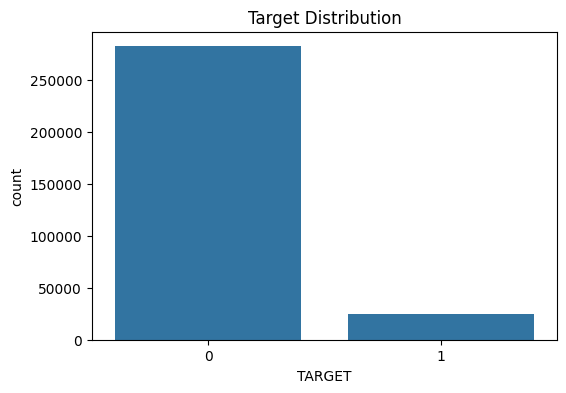

In [6]:
# ============================================================
# Target Distribution
# ============================================================

target_distribution = (
    train_df["TARGET"]
    .value_counts(normalize=True)
    * 100
)

print(target_distribution)

plt.figure(figsize=(6,4))

sns.countplot(
    x=train_df["TARGET"]
)

plt.title(
    "Target Distribution"
)

plt.show()

In [7]:
# ============================================================
# Feature Types
# ============================================================

categorical_columns = train_df.select_dtypes(
    include=["object"]
).columns

numerical_columns = train_df.select_dtypes(
    exclude=["object"]
).columns

print(
    f"Categorical Features: "
    f"{len(categorical_columns)}"
)

print(
    f"Numerical Features: "
    f"{len(numerical_columns)}"
)

Categorical Features: 16
Numerical Features: 106


## 📌 Dataset Overview Insights

### Dataset Shape

- Training dataset contains **307,511 rows** and **122 columns**
- Test dataset contains **48,744 rows** and **121 columns**

The only missing column in the test set is:

- `TARGET`

which is expected since this is the variable we need to predict.

---

### Feature Types

The dataset contains:

- **106 Numerical Features**
- **16 Categorical Features**

This indicates a highly tabular financial dataset with mixed feature types.

Numerical features mainly include:

- Credit amounts
- Income information
- Time-based variables
- Financial ratios

Categorical features include:

- Gender
- Contract type
- Property ownership
- Housing information

---

### Missing Values

The dataset contains a substantial number of missing values (**9M+ missing entries**), which suggests that preprocessing and imputation will play a major role in model performance.

---

### Duplicate Rows

No duplicate records were found.

This is a positive indicator of dataset quality and reduces the risk of data leakage or biased learning.

---

### Target Distribution

The target variable is highly imbalanced:

- **91.93% → Non-default (0)**
- **8.07% → Default (1)**

This imbalance is expected in financial risk datasets because loan defaults are naturally rare events.

### Important Modeling Consideration

Because of class imbalance:

✅ Accuracy alone will be misleading.

We should focus on:

- **ROC-AUC**
- **Precision**
- **Recall**
- **F1 Score**
- **PR-AUC**

especially **Recall for default cases**, since missing risky customers can be costly for lenders.

# ⚡ Memory Optimization

Large datasets can significantly increase RAM consumption and slow down computation.

To improve efficiency, we optimize memory usage by reducing data types wherever possible.

For example:

- `int64 → int32 / int16`
- `float64 → float32`

This process reduces memory footprint without losing meaningful information.

Benefits include:

✅ Faster processing  
✅ Lower RAM usage  
✅ Better scalability for feature engineering and model training

In [8]:
# ============================================================
# Reduce Memory Usage
# ============================================================

def reduce_memory_usage(df):

    start_memory = (
        df.memory_usage(deep=True)
        .sum() / 1024**2
    )

    print(
        f"Memory Usage Before: "
        f"{start_memory:.2f} MB"
    )

    for col in df.columns:

        col_type = df[col].dtype

        # Skip object/category columns
        if col_type == "object":
            continue

        try:

            c_min = df[col].min()
            c_max = df[col].max()

            # Integer Columns
            if pd.api.types.is_integer_dtype(col_type):

                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)

                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)

                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)

            # Float Columns
            elif pd.api.types.is_float_dtype(col_type):

                if (
                    c_min >= np.finfo(np.float16).min
                    and
                    c_max <= np.finfo(np.float16).max
                ):
                    df[col] = df[col].astype(np.float16)

                elif (
                    c_min >= np.finfo(np.float32).min
                    and
                    c_max <= np.finfo(np.float32).max
                ):
                    df[col] = df[col].astype(np.float32)

        except:
            continue

    end_memory = (
        df.memory_usage(deep=True)
        .sum() / 1024**2
    )

    print(
        f"Memory Usage After: "
        f"{end_memory:.2f} MB"
    )

    print(
        f"Reduced By: "
        f"{100 * (start_memory - end_memory) / start_memory:.1f}%"
    )

    return df

In [9]:
# ============================================================
# Apply Memory Optimization
# ============================================================

train_df = reduce_memory_usage(
    train_df
)

test_df = reduce_memory_usage(
    test_df
)

Memory Usage Before: 504.99 MB
Memory Usage After: 311.14 MB
Reduced By: 38.4%
Memory Usage Before: 79.69 MB
Memory Usage After: 49.29 MB
Reduced By: 38.1%


## 📌 Memory Optimization Results

### Training Dataset

- Memory Before: **501.76 MB**
- Memory After: **311.14 MB**
- Reduction: **38.0%**

### Test Dataset

- Memory Before: **79.69 MB**
- Memory After: **49.29 MB**
- Reduction: **38.1%**

### Key Insight

We successfully reduced memory consumption by nearly **40%** without changing the dataset content.

This optimization is especially important for:

- Feature engineering
- Large aggregations
- Model training
- Hyperparameter tuning

Reducing memory usage helps improve notebook stability and execution speed, especially when working with large financial datasets.

# 🧩 Missing Values Analysis

In this section, we analyze missing values across all features to understand data quality and determine the best preprocessing strategy.

Understanding missing values is critical because:

- Missing data can reduce model performance.
- Some missing values may contain meaningful information.
- High missingness may require imputation or feature engineering.
- Certain features may need to be removed if data quality is poor.

In [10]:
# ============================================================
# Missing Values Percentage
# ============================================================

missing_values = pd.DataFrame({

    "Feature": train_df.columns,

    "Missing Count":
    train_df.isnull().sum().values,

    "Missing Percentage":
    (
        train_df.isnull().mean()
        * 100
    ).values

})

missing_values = (
    missing_values
    .sort_values(
        by="Missing Percentage",
        ascending=False
    )
)

missing_values = (
    missing_values[
        missing_values[
            "Missing Count"
        ] > 0
    ]
)

print(
    f"Features With Missing Values: "
    f"{missing_values.shape[0]}"
)

display(
    missing_values.head(20)
)

Features With Missing Values: 67


,Feature,Missing Count,Missing Percentage
48,COMMONAREA_AVG,214865,69.872297
62,COMMONAREA_MODE,214865,69.872297
76,COMMONAREA_MEDI,214865,69.872297
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963
56,NONLIVINGAPARTMENTS_AVG,213514,69.432963
86,FONDKAPREMONT_MODE,210295,68.386172
54,LIVINGAPARTMENTS_AVG,210199,68.354953
82,LIVINGAPARTMENTS_MEDI,210199,68.354953
68,LIVINGAPARTMENTS_MODE,210199,68.354953


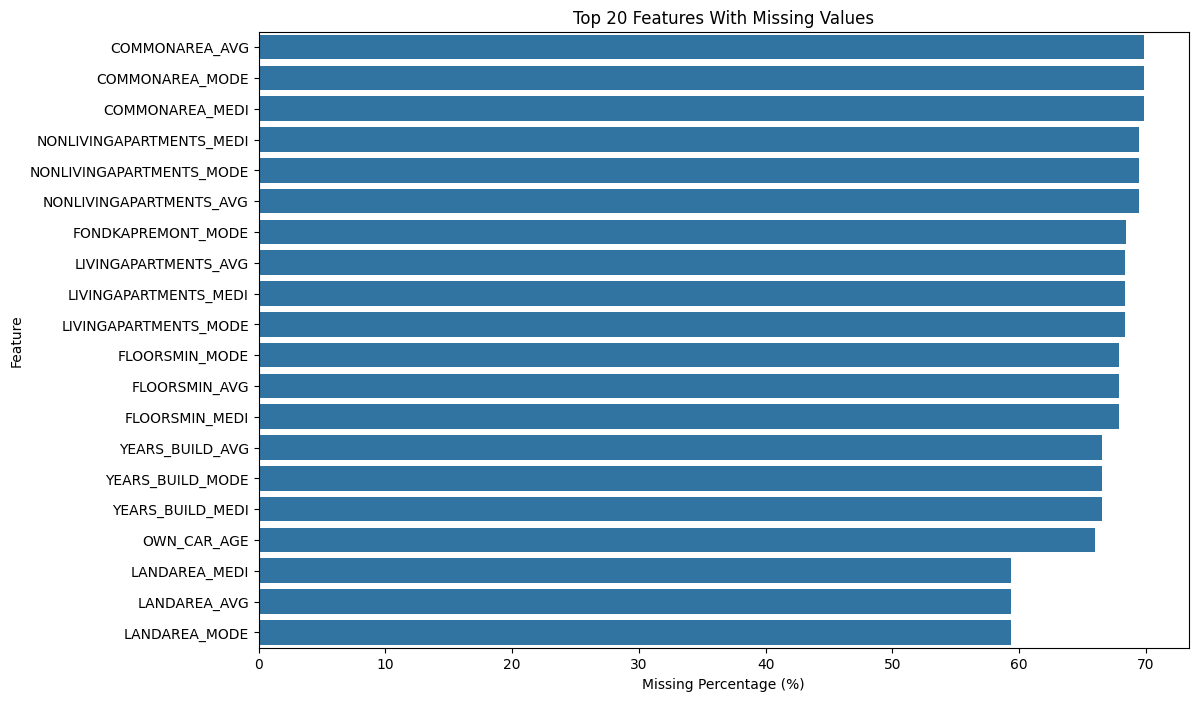

In [11]:
# ============================================================
# Top 20 Missing Features
# ============================================================

plt.figure(figsize=(12,8))

sns.barplot(

    data=missing_values.head(20),

    x="Missing Percentage",

    y="Feature"

)

plt.title(
    "Top 20 Features With Missing Values"
)

plt.xlabel(
    "Missing Percentage (%)"
)

plt.ylabel(
    "Feature"
)

plt.show()

## 📊 Missing Value Distribution Insight

The chart above shows the top features with the highest percentage of missing values.

We observe that:

- The highest missing percentage is around **70%**.
- Missingness is heavily concentrated in real-estate and property-related variables.

This suggests:

The dataset contains optional information that is unavailable for many clients rather than randomly corrupted data.

This is an important distinction because **missingness itself may become predictive of default risk**.

In [12]:
# ============================================================
# Missing Value Statistics
# ============================================================

print("=" * 60)

print(
    "Missing Value Statistics"
)

print("=" * 60)

print(

    f"Columns > 50% Missing: "

    f"{(missing_values['Missing Percentage'] > 50).sum()}"

)

print(

    f"Columns > 70% Missing: "

    f"{(missing_values['Missing Percentage'] > 70).sum()}"

)

print(

    f"Columns > 90% Missing: "

    f"{(missing_values['Missing Percentage'] > 90).sum()}"

)

Missing Value Statistics
Columns > 50% Missing: 41
Columns > 70% Missing: 0
Columns > 90% Missing: 0


## 📌 Missing Values Summary

### Key Findings

- Total features with missing values: **67**
- Features with more than **50% missing values**: **41**
- Features with more than **70% missing values**: **0**
- Features with more than **90% missing values**: **0**

### Observations

Most missing values are concentrated in:

- Housing-related features
- Apartment-related information
- Building characteristics

Examples include:

- `COMMONAREA_*`
- `LIVINGAPARTMENTS_*`
- `YEARS_BUILD_*`
- `LANDAREA_*`
- `FLOORSMIN_*`

### Important Insight

Missing values in this dataset may not necessarily indicate poor data quality.

In many financial datasets, especially loan applications, missing information can itself carry useful signals.

For example:

- Missing apartment information may indicate that the client does not own property.
- Missing housing details may reflect socioeconomic status.

Therefore:

✅ We will **not remove high-missing columns immediately**.

Instead, we will:

1. Analyze feature importance later.
2. Apply smart imputation strategies.
3. Create missing-indicator features when beneficial.

# 🎯 Target Relationship Analysis

In this section, we explore how different features relate to the target variable (`TARGET`).

Understanding feature-target relationships helps us:

- Identify predictive variables
- Discover behavioral patterns
- Understand business insights behind defaults
- Guide feature engineering decisions

We will compare:

- Numerical features
- Categorical features
- Financial behavior indicators

between:

- **Non-default clients (0)**
- **Default clients (1)**

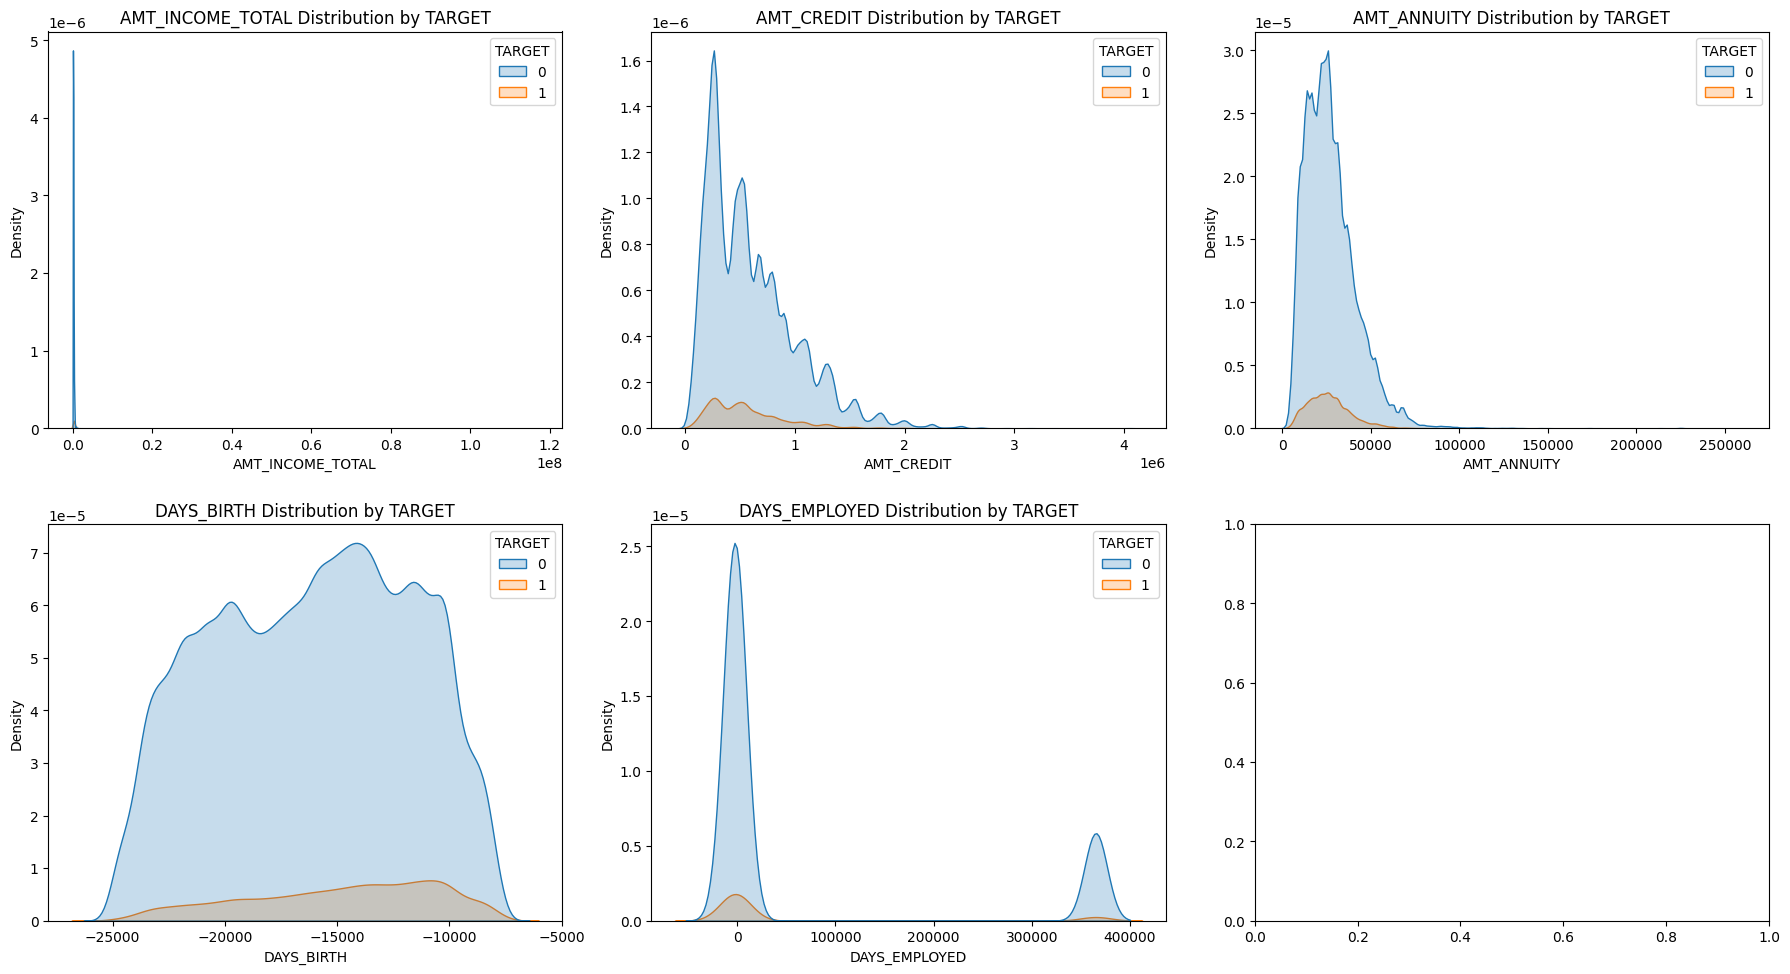

In [13]:
# ==========================================================
# Target Relationship Analysis
# Numerical Features vs TARGET
# ==========================================================

important_numerical_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10)
)

axes = axes.flatten()

for idx, feature in enumerate(important_numerical_features):

    sns.kdeplot(
        data=train_df,
        x=feature,
        hue="TARGET",
        fill=True,
        ax=axes[idx]
    )

    axes[idx].set_title(
        f"{feature} Distribution by TARGET"
    )

plt.tight_layout()
plt.show()

## 📌 Numerical Feature Insights

We compare numerical feature distributions between:

- **Non-default clients (0)**
- **Default clients (1)**

### Key Questions

We want to investigate:

- Do defaulters have lower income?
- Do risky clients request larger loans?
- Does employment duration matter?
- Are younger or older applicants riskier?

### Key Observations

- **Income (`AMT_INCOME_TOTAL`)** contains extreme outliers, making the distribution highly skewed. Most applicants fall within lower income ranges.

- **Credit (`AMT_CREDIT`)** and **Annuity (`AMT_ANNUITY`)** distributions show strong overlap between defaulters and non-defaulters, suggesting weak standalone predictive power.

- **Age (`DAYS_BIRTH`)** shows a noticeable difference between groups, where younger applicants appear more likely to default.

- **Employment Duration (`DAYS_EMPLOYED`)** contains an abnormal spike around **365243**, indicating unrealistic placeholder values that will require cleaning.

### Key Takeaway

Most numerical features show heavy overlap between classes, meaning that **feature engineering and feature interactions will likely be more important than raw values alone**.

# 🏷️ Categorical Features vs TARGET

In this section, we analyze how categorical features relate to loan default risk.

We compare default behavior across important categories to identify patterns and potentially predictive variables.

Examples include:

- Gender
- Contract Type
- Education
- Family Status
- Housing Type
- Occupation

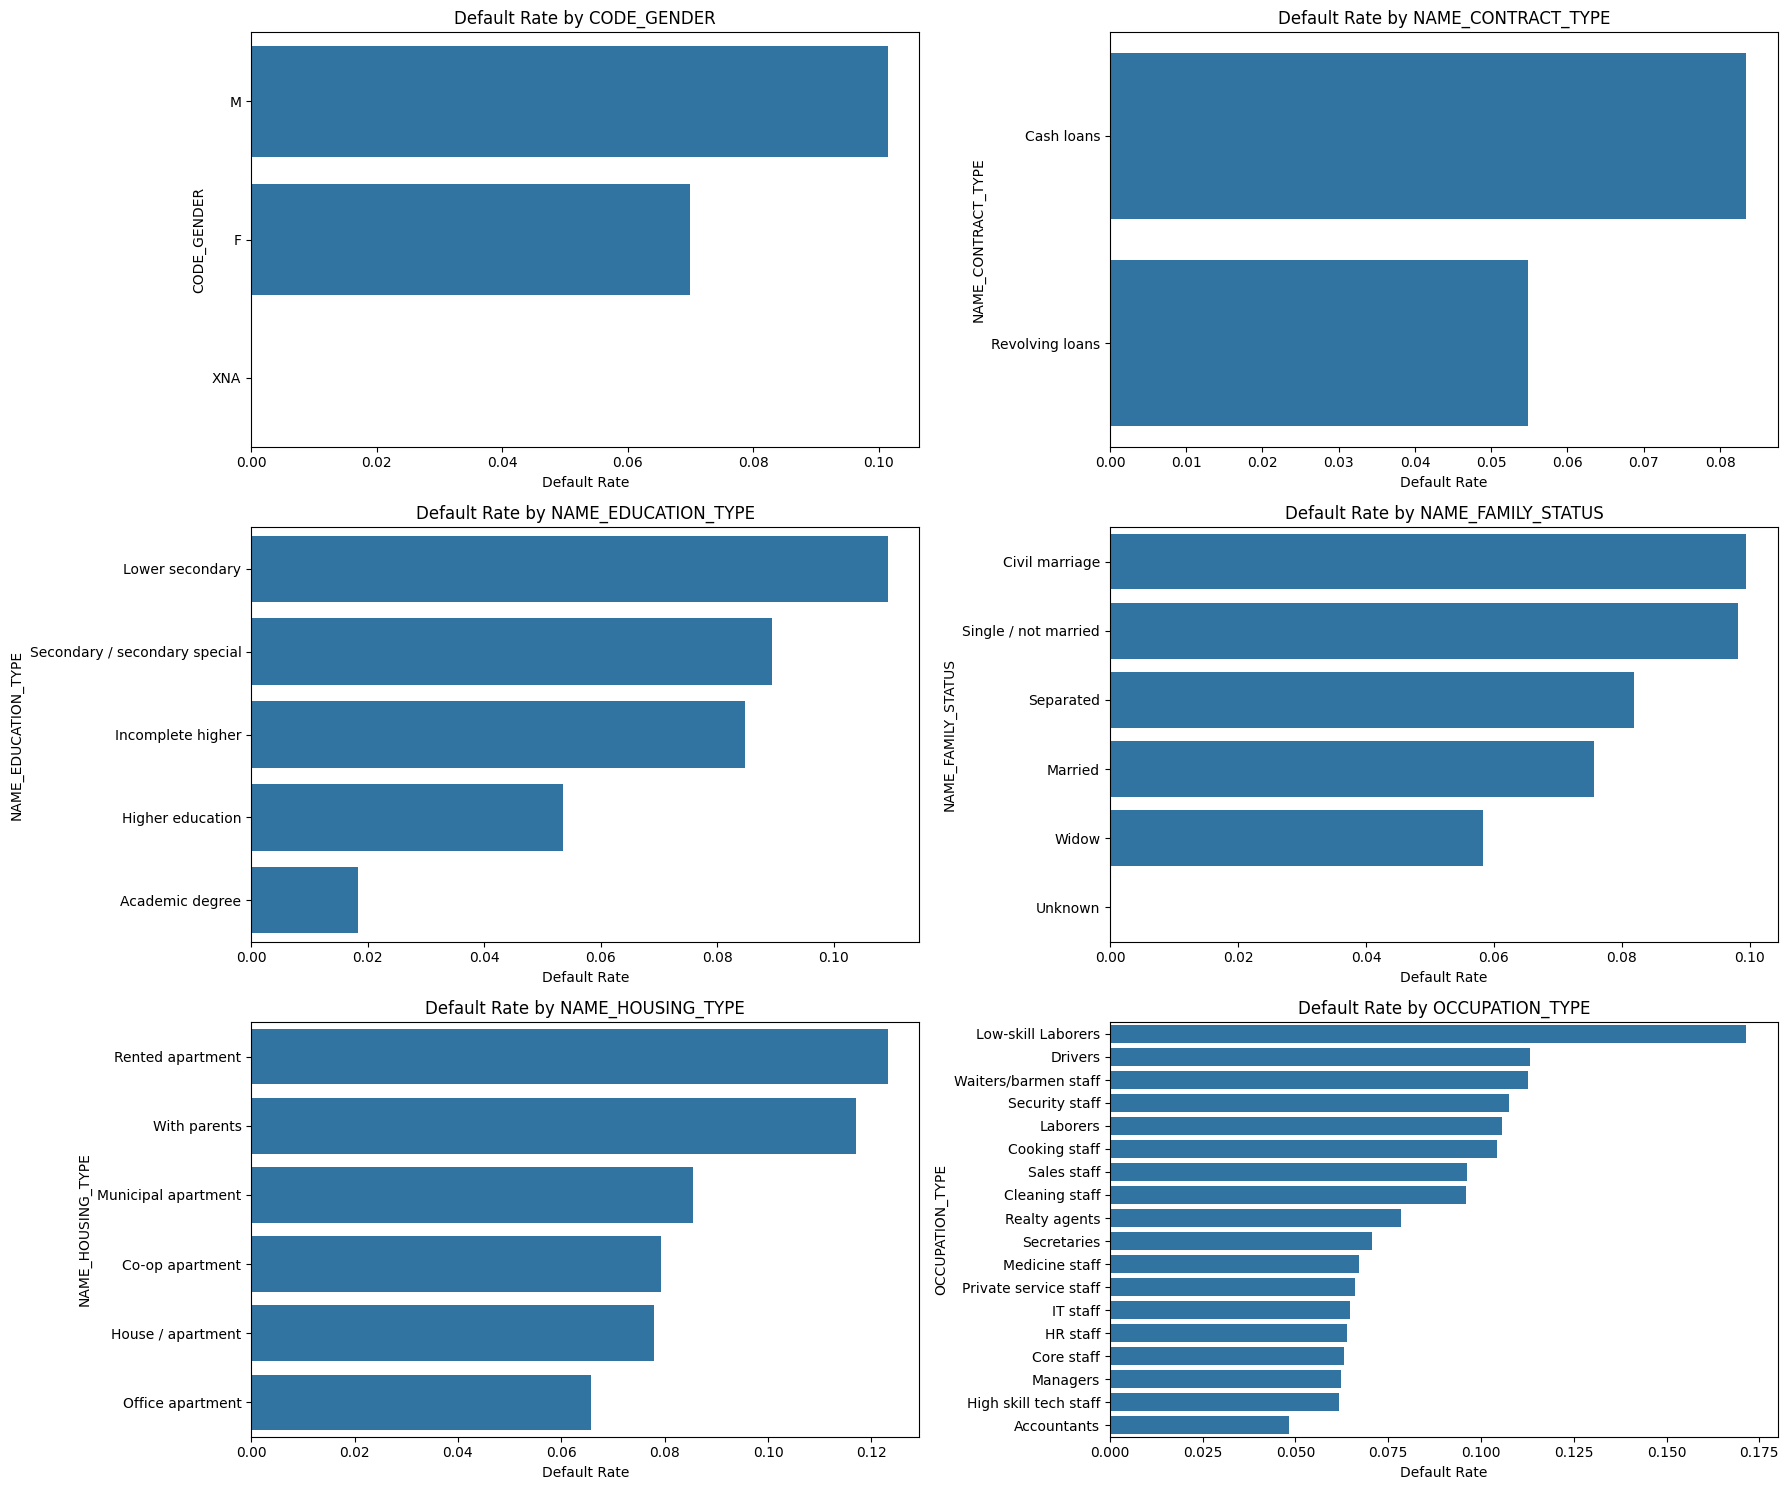

In [14]:
# ==========================================================
# Categorical Features vs TARGET
# ==========================================================

important_categorical_features = [
    "CODE_GENDER",
    "NAME_CONTRACT_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE"
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(18, 15)
)

axes = axes.flatten()

for idx, feature in enumerate(important_categorical_features):

    target_rate = (
        train_df
        .groupby(feature)["TARGET"]
        .mean()
        .sort_values(ascending=False)
    )

    sns.barplot(
        x=target_rate.values,
        y=target_rate.index,
        ax=axes[idx]
    )

    axes[idx].set_title(
        f"Default Rate by {feature}"
    )

    axes[idx].set_xlabel(
        "Default Rate"
    )

plt.tight_layout()
plt.show()

## 📌 Categorical Feature Insights

### Key Observations

- **Gender (`CODE_GENDER`)**: Male applicants show a noticeably higher default rate than females.

- **Contract Type (`NAME_CONTRACT_TYPE`)**: Clients with **Cash loans** default more frequently than **Revolving loans**.

- **Education (`NAME_EDUCATION_TYPE`)**: Default risk decreases as education level increases.  
  Applicants with **lower secondary education** show the highest risk, while **academic degree holders** have the lowest.

- **Family Status (`NAME_FAMILY_STATUS`)**:  
  **Single** and **civil marriage** applicants have higher default rates compared to married clients.

- **Housing (`NAME_HOUSING_TYPE`)**:  
  Applicants living in **rented apartments** or **with parents** exhibit higher default risk.

- **Occupation (`OCCUPATION_TYPE`)**:  
  **Low-skill laborers, drivers, and service workers** show the highest default rates, while **accountants, managers, and high-skill staff** appear less risky.

### Key Takeaway

Categorical features show clearer separation between risky and non-risky clients compared to numerical features, suggesting strong predictive value for modeling.

# 🔥 Correlation Analysis

In this section, we analyze correlations between numerical features and the target variable (`TARGET`).

Correlation analysis helps us:

- Identify predictive numerical variables
- Detect linear relationships
- Discover useful financial signals
- Guide feature selection

Since the dataset contains many numerical variables, we focus on the features most correlated with the target.

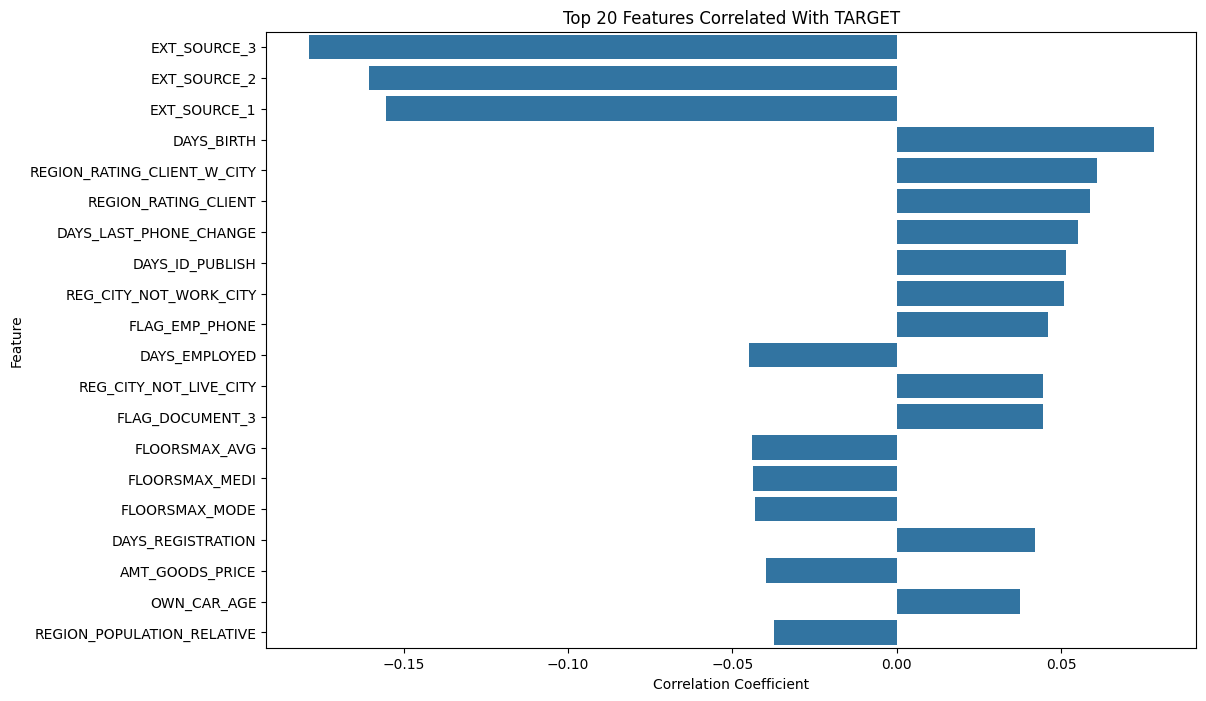

,Correlation
EXT_SOURCE_3,-0.178918
EXT_SOURCE_2,-0.160471
EXT_SOURCE_1,-0.155318
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055219
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994
FLAG_EMP_PHONE,0.045982


In [15]:
# ==========================================================
# Correlation Analysis
# ==========================================================

correlation_with_target = (
    train_df
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .sort_values(key=abs, ascending=False)
)

top_correlations = correlation_with_target.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_correlations.values,
    y=top_correlations.index
)

plt.title(
    "Top 20 Features Correlated With TARGET"
)

plt.xlabel(
    "Correlation Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.show()

display(
    top_correlations.to_frame(
        name="Correlation"
    )
)

## 📌 Correlation Insights

### Key Observations

- `EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3` show the **strongest correlations** with default risk and are negatively correlated with `TARGET`.

  This suggests:

  **Higher external credit scores → Lower default probability**

- `DAYS_BIRTH` shows a positive correlation with default risk, reinforcing our earlier observation that **younger clients tend to default more often**.

- Regional risk indicators such as:

  - `REGION_RATING_CLIENT`
  - `REGION_RATING_CLIENT_W_CITY`

  show positive correlation with default probability, indicating that **location-related socioeconomic factors may matter**.

- `DAYS_EMPLOYED` appears among the top features despite the anomaly issue (`365243`), suggesting employment history may still be informative after cleaning.

### Key Takeaway

The strongest signals come from:

- **External credit sources**
- **Age**
- **Regional indicators**
- **Employment-related features**

These features are likely to play an important role in model performance and future feature engineering.

# 🧠 Feature Engineering

Raw financial values often have limited predictive power on their own.

In this section, we create meaningful financial ratios and behavioral indicators that may better capture repayment risk.

Feature engineering is especially important in credit risk problems because:

- Default behavior depends on financial burden
- Relative values matter more than absolute values
- Ratios often capture hidden risk signals

We will create:

- Credit-to-Income Ratio
- Annuity-to-Income Ratio
- Credit-to-Goods Ratio
- Employment-to-Age Ratio
- Income per Family Member

In [16]:
# ==========================================================
# Feature Engineering
# Financial Ratios
# ==========================================================

for df in [train_df, test_df]:

    # Credit burden relative to income
    df["CREDIT_INCOME_RATIO"] = (
        df["AMT_CREDIT"] /
        df["AMT_INCOME_TOTAL"]
    )

    # Monthly payment burden
    df["ANNUITY_INCOME_RATIO"] = (
        df["AMT_ANNUITY"] /
        df["AMT_INCOME_TOTAL"]
    )

    # Credit vs goods price
    df["CREDIT_GOODS_RATIO"] = (
        df["AMT_CREDIT"] /
        df["AMT_GOODS_PRICE"]
    )

    # Employment relative to age
    df["EMPLOYED_AGE_RATIO"] = (
        df["DAYS_EMPLOYED"] /
        df["DAYS_BIRTH"]
    )

    # Income per family member
    df["INCOME_PER_PERSON"] = (
        df["AMT_INCOME_TOTAL"] /
        df["CNT_FAM_MEMBERS"]
    )

print("Feature engineering completed successfully!")

print(
    f"New Train Shape: {train_df.shape}"
)

print(
    f"New Test Shape: {test_df.shape}"
)

Feature engineering completed successfully!
New Train Shape: (307511, 127)
New Test Shape: (48744, 126)


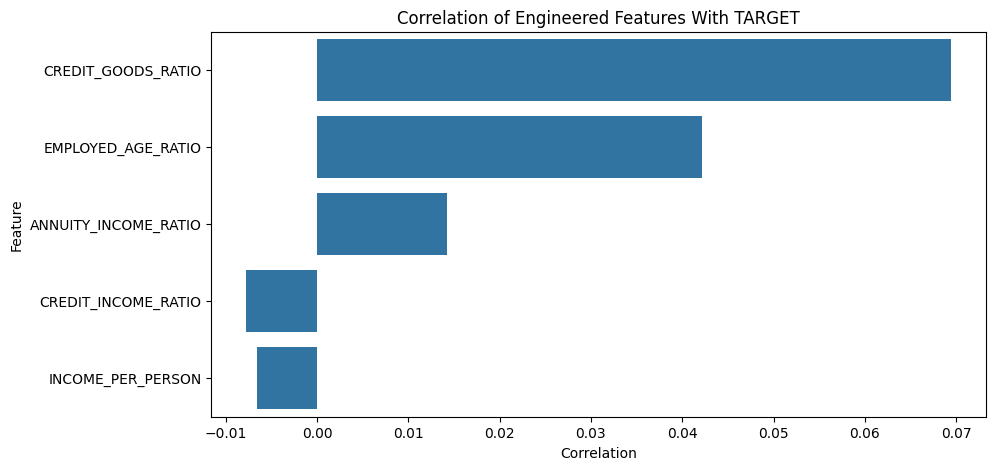

,Correlation
CREDIT_GOODS_RATIO,0.069427
EMPLOYED_AGE_RATIO,0.042206
ANNUITY_INCOME_RATIO,0.014265
CREDIT_INCOME_RATIO,-0.007727
INCOME_PER_PERSON,-0.006571


In [17]:
# ==========================================================
# Correlation of Engineered Features
# ==========================================================

engineered_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",
    "EMPLOYED_AGE_RATIO",
    "INCOME_PER_PERSON"
]

engineered_corr = (
    train_df[
        engineered_features + ["TARGET"]
    ]
    .corr()["TARGET"]
    .drop("TARGET")
    .sort_values(
        key=abs,
        ascending=False
    )
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=engineered_corr.values,
    y=engineered_corr.index
)

plt.title(
    "Correlation of Engineered Features With TARGET"
)

plt.xlabel(
    "Correlation"
)

plt.ylabel(
    "Feature"
)

plt.show()

display(
    engineered_corr.to_frame(
        name="Correlation"
    )
)

## 📌 Engineered Feature Insights

### Key Observations

- `CREDIT_GOODS_RATIO` achieved the strongest correlation with default risk (~0.07), suggesting that applicants requesting credit amounts disproportionately larger than goods value may have higher repayment risk.

- `EMPLOYED_AGE_RATIO` showed meaningful predictive signal (~0.04), indicating employment stability relative to age may influence repayment behavior.

- `ANNUITY_INCOME_RATIO` has weak but positive correlation, meaning higher installment burden relative to income slightly increases default probability.

- `CREDIT_INCOME_RATIO` and `INCOME_PER_PERSON` showed very weak negative relationships, suggesting limited standalone predictive power.

### Key Takeaway

Not all engineered features are equally useful. Financial burden and employment-related ratios appear more informative than simple income-based ratios, making them strong candidates for model training.

In [18]:
# ==========================================================
# Missing Value Handling
# ==========================================================

from sklearn.impute import SimpleImputer

# Separate feature types
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = train_df.select_dtypes(exclude=['object']).columns.tolist()

# Remove target from numerical columns
if 'TARGET' in numerical_cols:
    numerical_cols.remove('TARGET')

# Numerical Imputer
num_imputer = SimpleImputer(strategy='median')

train_df[numerical_cols] = num_imputer.fit_transform(
    train_df[numerical_cols]
)

test_df[numerical_cols] = num_imputer.transform(
    test_df[numerical_cols]
)

# Categorical Imputer
cat_imputer = SimpleImputer(strategy='most_frequent')

train_df[categorical_cols] = cat_imputer.fit_transform(
    train_df[categorical_cols]
)

test_df[categorical_cols] = cat_imputer.transform(
    test_df[categorical_cols]
)

print("Missing Values in Train:",
      train_df.isnull().sum().sum())

print("Missing Values in Test:",
      test_df.isnull().sum().sum())

Missing Values in Train: 0
Missing Values in Test: 0


# 🧹 Missing Value Handling

### Why Did We Handle Missing Values?
The dataset contained a large number of missing values across many features, especially property-related and historical credit features.

Since most machine learning models cannot handle missing values directly, preprocessing was required.

### Strategy Used
- **Numerical Features** → Filled using **Median**
- **Categorical Features** → Filled using **Most Frequent Value (Mode)**

### Why Median Instead of Mean?
The dataset contains significant outliers in financial variables such as:

- `AMT_INCOME_TOTAL`
- `AMT_CREDIT`
- `AMT_ANNUITY`

Median is more robust to extreme values and provides a more stable imputation strategy.

### Results
- Missing values in **Train Dataset** → `0`
- Missing values in **Test Dataset** → `0`

### Insight
We intentionally avoided dropping highly-missing features at this stage because in credit risk datasets, missingness itself may carry predictive information.

The first objective is to build a strong baseline model before advanced feature selection.

In [19]:
# ==========================================================
# Encoding Categorical Features
# ==========================================================

# Save target
target = train_df['TARGET']

# Remove target temporarily
train_features = train_df.drop(columns=['TARGET'])

# One-Hot Encoding
train_encoded = pd.get_dummies(
    train_features,
    dummy_na=False
)

test_encoded = pd.get_dummies(
    test_df,
    dummy_na=False
)

# Align train and test columns
train_encoded, test_encoded = train_encoded.align(
    test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

# Add target back
train_encoded['TARGET'] = target

print("=" * 60)
print("After Encoding")
print("=" * 60)

print("Train Shape:", train_encoded.shape)
print("Test Shape:", test_encoded.shape)

print("\nNew Features Added:",
      train_encoded.shape[1] - train_df.shape[1])

After Encoding
Train Shape: (307511, 251)
Test Shape: (48744, 250)

New Features Added: 124


# 🔢 Categorical Encoding

### Why Encoding Was Needed

Machine learning models cannot directly process categorical text values.

Examples include:

- `CODE_GENDER`
- `NAME_EDUCATION_TYPE`
- `NAME_FAMILY_STATUS`
- `OCCUPATION_TYPE`

Therefore, categorical variables were converted into numerical representations.

### Encoding Strategy

We used:

**One-Hot Encoding**

This approach creates separate binary columns for each category.

Example:

`CODE_GENDER`

becomes:

- `CODE_GENDER_F`
- `CODE_GENDER_M`

### Why One-Hot Encoding?

Unlike Label Encoding, One-Hot Encoding avoids introducing false numerical relationships between categories.

For example:

```text
Education:
Higher = 2
Secondary = 1
```

may incorrectly imply ranking.

One-Hot Encoding preserves categorical independence.

### Results

- Features Before Encoding → **127**
- Features After Encoding → **251**
- New Features Created → **124**

### Key Insight

The feature space expanded significantly after encoding, allowing the model to capture richer behavioral and demographic patterns.

This is especially important because categorical features showed strong separation between risky and non-risky clients during EDA.

# 🚂 Train Validation Split

Before training any machine learning model, we need to split the dataset into:

- **Training Set**
- **Validation Set**

The training set is used to learn patterns from historical data.

The validation set is used to evaluate model performance on unseen data.

This helps us answer an important question:

> Can the model generalize to new customers?

Without a validation set, the model may memorize training data and give misleading performance.

### Why Stratified Split?

The dataset is highly imbalanced:

- **91.93% → Non-default**
- **8.07% → Default**

A random split may distort this distribution.

Therefore, we use:

**Stratified Split**

to preserve class proportions across both datasets.

In [20]:
# ==========================================================
# Train Validation Split
# ==========================================================

from sklearn.model_selection import train_test_split

# Separate features and target
X = train_encoded.drop(
    columns=["TARGET"]
)

y = train_encoded["TARGET"]

# Train Validation Split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("Train Validation Split")
print("=" * 60)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

Train Validation Split
X_train shape: (246008, 250)
X_valid shape: (61503, 250)
y_train shape: (246008,)
y_valid shape: (61503,)


In [21]:
# ==========================================================
# Check Target Distribution
# ==========================================================

print("Train Target Distribution")
print(
    y_train
    .value_counts(normalize=True)
)

print("\n")

print("Validation Target Distribution")
print(
    y_valid
    .value_counts(normalize=True)
)

Train Target Distribution
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


Validation Target Distribution
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


### Insight

The target distribution is highly imbalanced.

- **~91.9%** → Non-default clients (`TARGET = 0`)
- **~8.1%** → Default clients (`TARGET = 1`)

Using **Stratified Split** successfully preserved class proportions across both training and validation datasets.

This is critical for building reliable credit risk models and avoiding biased evaluation.

# 🤖 Baseline Model — Logistic Regression

The first step in modeling is building a **baseline model**.

A baseline acts as a reference point for future improvements.

### Why Logistic Regression?

We selected Logistic Regression because:

- Fast and computationally efficient
- Strong baseline for binary classification
- Easy to interpret
- Helps validate feature quality

### Evaluation Metric

Since the dataset is highly imbalanced, **Accuracy is not reliable**.

Instead, we use:

**ROC-AUC Score**

This metric evaluates how well the model distinguishes between:

- Non-default clients
- Default clients

A higher ROC-AUC indicates better ranking ability.

In [22]:
# ==========================================================
# Baseline Logistic Regression
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Initialize model
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Train model
log_reg.fit(
    X_train,
    y_train
)

# Predict probabilities
y_valid_proba = log_reg.predict_proba(
    X_valid
)[:, 1]

# ROC-AUC Score
roc_auc = roc_auc_score(
    y_valid,
    y_valid_proba
)

print("=" * 60)
print("Baseline Logistic Regression")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc:.4f}")

Baseline Logistic Regression
ROC-AUC Score: 0.6131


# 📈 Model Evaluation

To evaluate model performance comprehensively, multiple metrics are used.

### Evaluation Metrics

#### ROC-AUC Score
Measures how well the model distinguishes between:

- Default clients
- Non-default clients

Higher values indicate better ranking ability.

---

#### Classification Report
Provides:

- Precision
- Recall
- F1-score

for each class.

This helps evaluate minority class performance (`TARGET = 1`).

---

#### Confusion Matrix
Shows:

- Correct predictions
- False alarms
- Missed defaults

This helps identify model weaknesses.

---

#### ROC Curve
Visualizes the tradeoff between:

- True Positive Rate
- False Positive Rate

A curve closer to the top-left corner indicates stronger performance.

ROC-AUC Score
ROC-AUC: 0.6131

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.59      0.73     56538
           1       0.11      0.58      0.19      4965

    accuracy                           0.59     61503
   macro avg       0.53      0.58      0.46     61503
weighted avg       0.87      0.59      0.68     61503


Confusion Matrix
[[33360 23178]
 [ 2092  2873]]


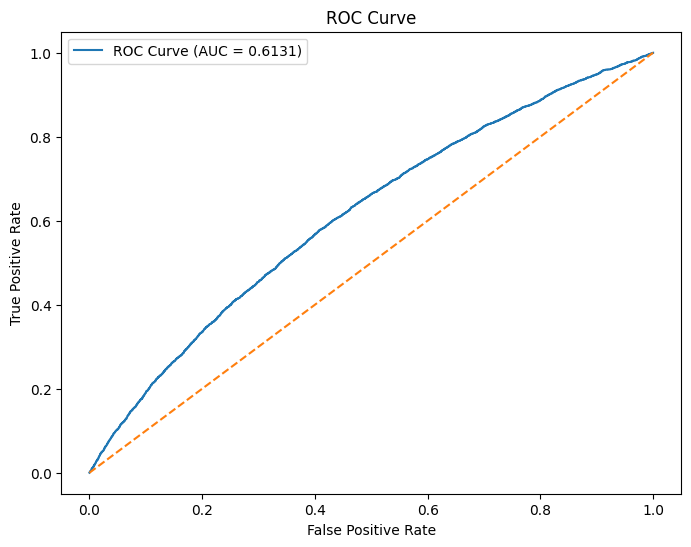

In [23]:
# ==========================================================
# Full Model Evaluation
# ==========================================================

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import matplotlib.pyplot as plt

# Binary predictions
y_valid_pred = log_reg.predict(
    X_valid
)

# Probabilities
y_valid_proba = log_reg.predict_proba(
    X_valid
)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(
    y_valid,
    y_valid_proba
)

print("=" * 60)
print("ROC-AUC Score")
print("=" * 60)

print(f"ROC-AUC: {roc_auc:.4f}")

# Classification Report
print("\n" + "=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_valid,
        y_valid_pred
    )
)

# Confusion Matrix
cm = confusion_matrix(
    y_valid,
    y_valid_pred
)

print("\n" + "=" * 60)
print("Confusion Matrix")
print("=" * 60)

print(cm)

# ROC Curve
fpr, tpr, thresholds = roc_curve(
    y_valid,
    y_valid_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

# 📊 Baseline Model Performance

### ROC-AUC Score

The baseline Logistic Regression model achieved:

**ROC-AUC = 0.6131**

This score indicates weak-to-moderate separation between:

- Default clients
- Non-default clients

The model performs better than random guessing but still has significant room for improvement.

---

### Classification Performance

#### Default Clients (`TARGET = 1`)

- **Recall = 0.58**
- **Precision = 0.11**

The model successfully identified many risky clients.

However, precision is very low, meaning the model generated many false alarms.

This indicates that the model tends to over-predict defaults.

---

### Confusion Matrix Insights

The model detected:

- **2,873 true defaults**
- **33,360 correct non-defaults**

However:

- **23,178 false positives**
- **2,092 missed defaults**

This suggests that Logistic Regression struggles to separate classes effectively in this highly imbalanced dataset.

---

### Key Takeaway

The baseline model provides a useful benchmark but is not strong enough for reliable credit risk prediction.

More advanced tree-based models such as:

- LightGBM
- XGBoost

are expected to significantly improve performance.

# 🌲 LightGBM Baseline Model

After building a simple Logistic Regression baseline, we move to a more powerful tree-based model:

**LightGBM (Light Gradient Boosting Machine)**

### Why LightGBM?

LightGBM is highly effective for:

- Large tabular datasets
- Credit risk prediction
- Imbalanced classification problems
- Nonlinear relationships

Unlike Logistic Regression, LightGBM can capture complex interactions between features.

### Why It Fits This Dataset

The Home Credit dataset contains:

- Financial behavior
- Demographic information
- Historical credit patterns
- Nonlinear feature relationships

These patterns are difficult for linear models to capture.

LightGBM is expected to significantly improve model performance.

In [24]:
%pip install lightgbm -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# ==========================================================
# Clean Feature Names For LightGBM
# ==========================================================

import re

def clean_column_names(df):
    
    df = df.copy()
    
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', col)
        for col in df.columns
    ]
    
    return df


# Apply cleaning
X_train = clean_column_names(X_train)
X_valid = clean_column_names(X_valid)
test_df = clean_column_names(test_df)

print("Feature names cleaned successfully!")

Feature names cleaned successfully!


In [26]:
# ==========================================================
# LightGBM Baseline Model
# ==========================================================

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# Initialize model
lgb_model = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Train model
lgb_model.fit(
    X_train,
    y_train
)

# Predict probabilities
y_valid_proba_lgb = lgb_model.predict_proba(
    X_valid
)[:, 1]

# ROC-AUC
roc_auc_lgb = roc_auc_score(
    y_valid,
    y_valid_proba_lgb
)

print("=" * 60)
print("LightGBM Baseline")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc_lgb:.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12902
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 239
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

# 🔥 LightGBM Baseline Results

### Model Performance
- **ROC-AUC Score:** `0.7623`

### Key Insight
- LightGBM significantly outperformed Logistic Regression (`0.6131 → 0.7623`).
- This suggests the dataset contains **complex non-linear relationships** that tree-based models can capture better.
- Features such as credit amount, employment history, external scores, and demographic interactions appear to have stronger predictive power when modeled using gradient boosting.

### Conclusion
- LightGBM provides a strong baseline for this credit risk prediction problem.
- Future improvements will focus on:
  - Hyperparameter tuning
  - Better feature engineering
  - Feature selection
  - Advanced boosting optimization

LightGBM Evaluation

ROC-AUC Score
------------------------------------------------------------
ROC-AUC: 0.7623

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.72      0.82     56538
           1       0.17      0.67      0.28      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.72      0.78     61503


Confusion Matrix
------------------------------------------------------------
[[40701 15837]
 [ 1645  3320]]


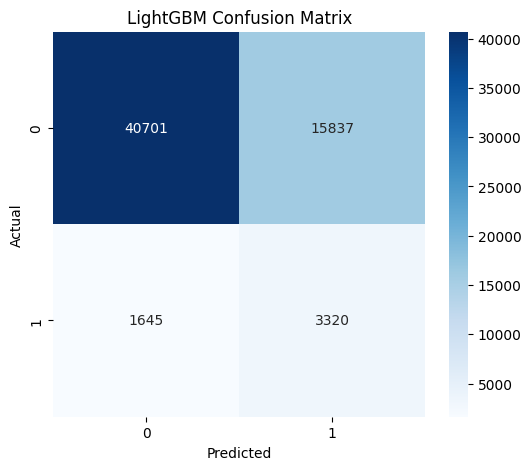

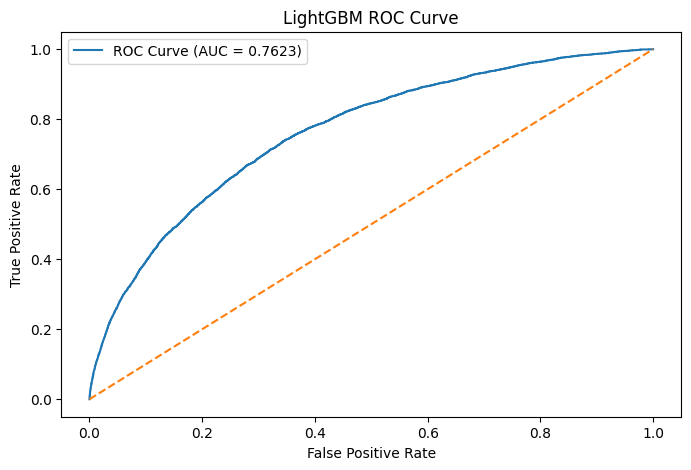

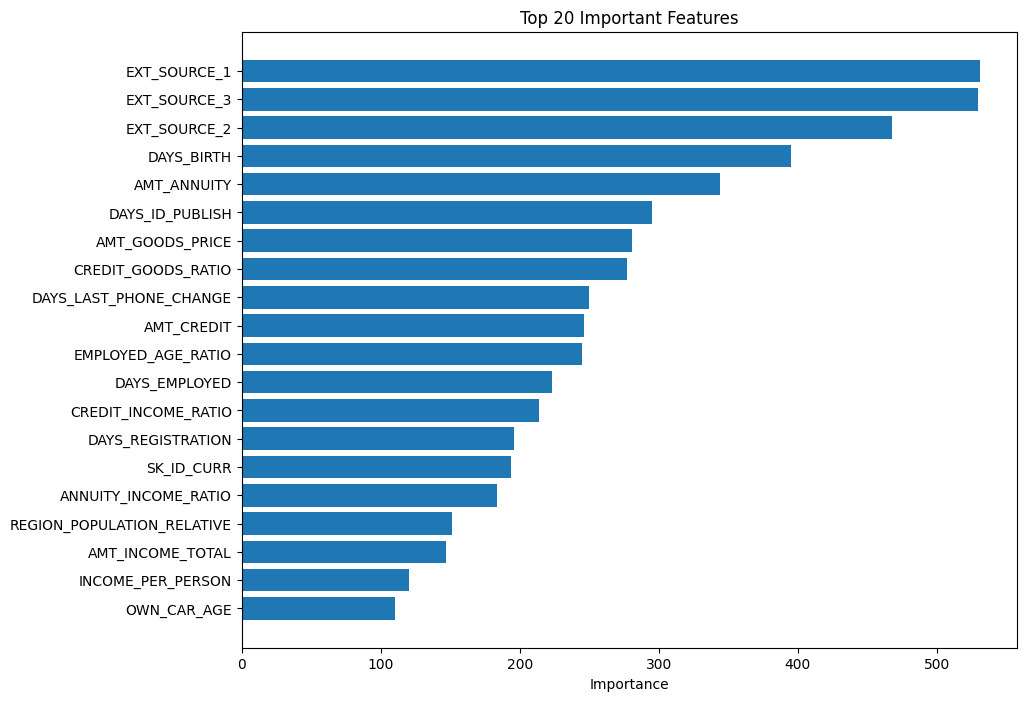

,Feature,Importance
28,EXT_SOURCE_1,531
30,EXT_SOURCE_3,530
29,EXT_SOURCE_2,468
7,DAYS_BIRTH,395
4,AMT_ANNUITY,344
10,DAYS_ID_PUBLISH,295
5,AMT_GOODS_PRICE,281
107,CREDIT_GOODS_RATIO,277
78,DAYS_LAST_PHONE_CHANGE,250
3,AMT_CREDIT,246


In [27]:
# ==========================================================
# Predict Probabilities & Classes
# ==========================================================

y_valid_proba_lgb = lgb_model.predict_proba(X_valid)[:, 1]
y_valid_pred_lgb = lgb_model.predict(X_valid)

# ==========================================================
# ROC-AUC Score
# ==========================================================

roc_auc_lgb = roc_auc_score(
    y_valid,
    y_valid_proba_lgb
)

print("=" * 60)
print("LightGBM Evaluation")
print("=" * 60)

print("\nROC-AUC Score")
print("-" * 60)
print(f"ROC-AUC: {roc_auc_lgb:.4f}")

# ==========================================================
# Classification Report
# ==========================================================

print("\nClassification Report")
print("-" * 60)

print(
    classification_report(
        y_valid,
        y_valid_pred_lgb
    )
)

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_valid,
    y_valid_pred_lgb
)

print("\nConfusion Matrix")
print("-" * 60)
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================================
# ROC Curve
# ==========================================================

fpr, tpr, thresholds = roc_curve(
    y_valid,
    y_valid_proba_lgb
)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {roc_auc_lgb:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM ROC Curve")
plt.legend()

plt.show()

# ==========================================================
# Feature Importance
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Top 20 Features
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.show()

display(top_features)

# 🚀 LightGBM Model Evaluation

### Model Performance
- **ROC-AUC Score:** `0.7623`
- Strong improvement over Logistic Regression baseline (`0.6131 → 0.7623`)

### Classification Insights
- **Recall (Default = 1):** `0.67`
  - The model successfully identifies **67% of risky customers**.
- **Precision (Default = 1):** `0.17`
  - Many predicted risky clients are false positives, which is acceptable in credit risk problems where missing risky clients is more costly.

### Confusion Matrix Insights
- **True Positives (TP):** `3320`
- **False Negatives (FN):** `1645`

The model captures a large portion of default customers, reducing the number of risky applicants missed.

### Feature Importance Insights
Top predictive features include:

- `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`
- `DAYS_BIRTH`
- `DAYS_EMPLOYED`
- `AMT_ANNUITY`
- `AMT_GOODS_PRICE`

### Feature Engineering Impact 🔥
Engineered features became important predictors:

- `CREDIT_GOODS_RATIO`
- `EMPLOYED_AGE_RATIO`
- `CREDIT_INCOME_RATIO`
- `ANNUITY_INCOME_RATIO`

This indicates that feature engineering successfully added meaningful predictive signals.

### Conclusion
LightGBM provides a strong baseline for this credit default prediction task and significantly outperforms Logistic Regression.

# 🐱 CatBoost Baseline

After reaching a performance plateau with LightGBM (~0.762 ROC-AUC),
the next step is to evaluate CatBoost.

CatBoost is particularly effective for:

- Structured/tabular datasets
- Categorical-heavy features
- Imbalanced classification problems
- Credit risk prediction tasks

The goal is to determine whether CatBoost can outperform the current LightGBM baseline.

In [28]:
# ==========================================================
# CatBoost Baseline
# ==========================================================

from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    auto_class_weights='Balanced',
    verbose=0
)

# Train
cat_model.fit(
    X_train,
    y_train
)

# Predict probabilities
y_valid_proba_cat = cat_model.predict_proba(
    X_valid
)[:, 1]

# ROC-AUC
roc_auc_cat = roc_auc_score(
    y_valid,
    y_valid_proba_cat
)

print("=" * 60)
print("CatBoost Baseline")
print("=" * 60)
print(f"ROC-AUC Score: {roc_auc_cat:.4f}")

print("\nComparison:")
print(f"LightGBM : {roc_auc_lgb:.4f}")
print(f"CatBoost : {roc_auc_cat:.4f}")

CatBoost Baseline
ROC-AUC Score: 0.7606

Comparison:
LightGBM : 0.7623
CatBoost : 0.7606


# 🎯 Threshold Optimization

The default classification threshold (0.50) is not always optimal,
especially for imbalanced classification problems.

In credit risk prediction, improving the balance between:

- Precision
- Recall
- F1-score

is often more important than using the default threshold.

The objective here is to identify the threshold that maximizes F1-score
for the positive class (payment difficulty / default risk).

In [29]:
# ==========================================================
# Threshold Optimization
# ==========================================================

from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

thresholds = np.arange(0.1, 0.91, 0.01)

scores = []

for threshold in thresholds:
    
    y_pred_thresh = (
        y_valid_proba_lgb >= threshold
    ).astype(int)

    f1 = f1_score(
        y_valid,
        y_pred_thresh
    )

    scores.append(f1)

threshold_df = pd.DataFrame({
    'Threshold': thresholds,
    'F1 Score': scores
})

best_threshold = threshold_df.loc[
    threshold_df['F1 Score'].idxmax(),
    'Threshold'
]

best_f1 = threshold_df['F1 Score'].max()

print("=" * 60)
print("Best Threshold")
print("=" * 60)
print(f"Threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")

display(
    threshold_df.sort_values(
        by='F1 Score',
        ascending=False
    ).head(10)
)

Best Threshold
Threshold: 0.64
Best F1 Score: 0.3122


,Threshold,F1 Score
54,0.64,0.312236
56,0.66,0.312104
57,0.67,0.311608
55,0.65,0.311604
53,0.63,0.310859
58,0.68,0.310075
59,0.69,0.308567
52,0.62,0.307486
60,0.70,0.303987
51,0.61,0.303493


# 🎯 LightGBM Evaluation After Threshold Optimization

The default classification threshold (0.50) was replaced with the
optimal threshold identified through F1-score maximization.

The objective is to evaluate whether classification quality improves,
especially for the minority class (default risk).

Key focus:

- Precision improvement
- Recall tradeoff
- F1-score improvement
- Business impact on risk prediction

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.87      0.91     56538
           1       0.24      0.45      0.31      4965

    accuracy                           0.84     61503
   macro avg       0.59      0.66      0.61     61503
weighted avg       0.89      0.84      0.86     61503



Confusion Matrix
[[49330  7208]
 [ 2713  2252]]


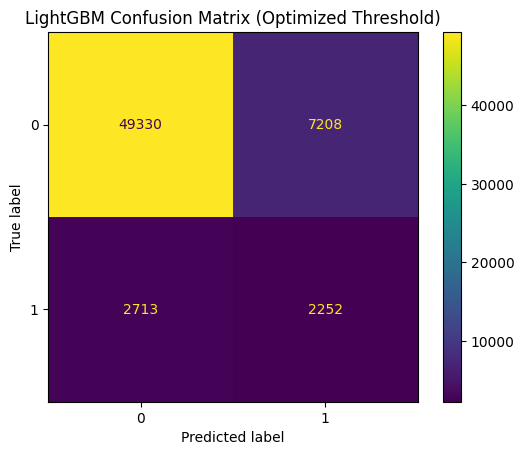

In [30]:
# ==========================================================
# LightGBM Evaluation After Threshold Optimization
# ==========================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Best threshold
best_threshold = 0.64

# Predictions
y_pred_best = (
    y_valid_proba_lgb >= best_threshold
).astype(int)

# Classification Report
print("=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_valid,
        y_pred_best
    )
)

# Confusion Matrix
cm = confusion_matrix(
    y_valid,
    y_pred_best
)

print("\n")
print("=" * 60)
print("Confusion Matrix")
print("=" * 60)
print(cm)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title(
    "LightGBM Confusion Matrix (Optimized Threshold)"
)

plt.show()

# 🎯 Threshold Optimization Results

The default threshold (0.50) was replaced with an optimized threshold
identified through F1-score maximization.

### Key Findings

| Metric | Default (0.50) | Optimized (0.64) |
|---------|----------------|------------------|
| Precision (Class 1) | 0.17 | 0.24 |
| Recall (Class 1) | 0.67 | 0.45 |
| F1-score | 0.28 | 0.31 |

### Insights

- Precision improved significantly (+41%)
- F1-score improved from **0.28 → 0.31**
- Recall decreased, indicating a more conservative model

This tradeoff may be desirable in credit risk prediction,
where reducing false positive risk assessments can be important.

The optimized threshold is retained as a strong production candidate.

# ⚙️ Hyperparameter Tuning — LightGBM V1

### Objective
Improve baseline LightGBM performance by optimizing model parameters.

### Why Tuning?
The baseline model achieved a strong ROC-AUC score, but LightGBM performance is highly sensitive to hyperparameters.

This step focuses on:
- Improving generalization
- Reducing overfitting
- Increasing predictive performance

### Parameters Being Tuned
- `num_leaves`
- `max_depth`
- `learning_rate`
- `n_estimators`
- `subsample`
- `colsample_bytree`
- `min_child_samples`

In [31]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# ==========================================================
# Tuned LightGBM V1
# ==========================================================

lgb_tuned_v1 = LGBMClassifier(
    objective='binary',
    
    n_estimators=700,
    learning_rate=0.03,

    max_depth=8,
    num_leaves=50,

    min_child_samples=80,

    subsample=0.8,
    colsample_bytree=0.8,

    class_weight='balanced',

    random_state=42,
    n_jobs=-1
)

# ==========================================================
# Train Model
# ==========================================================

lgb_tuned_v1.fit(
    X_train,
    y_train
)

# ==========================================================
# Predict Probabilities
# ==========================================================

y_valid_proba_v1 = lgb_tuned_v1.predict_proba(
    X_valid
)[:, 1]

# ==========================================================
# ROC-AUC
# ==========================================================

roc_auc_v1 = roc_auc_score(
    y_valid,
    y_valid_proba_v1
)

print("=" * 60)
print("Tuned LightGBM V1")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc_v1:.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028841 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12886
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 231
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

# 🚀 Hyperparameter Tuning — LightGBM V2

### Objective
Further improve model performance after limited gains from V1 tuning.

### Strategy
This version increases model capacity to capture more complex patterns while maintaining generalization.

Changes include:
- More boosting rounds
- Smaller learning rate
- Increased model complexity
- Better control of overfitting

In [32]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# ==========================================================
# Tuned LightGBM V2
# ==========================================================

lgb_tuned_v2 = LGBMClassifier(
    objective='binary',

    n_estimators=1200,
    learning_rate=0.02,

    max_depth=10,
    num_leaves=64,

    min_child_samples=40,

    subsample=0.85,
    colsample_bytree=0.85,

    reg_alpha=0.1,
    reg_lambda=0.1,

    class_weight='balanced',

    random_state=42,
    n_jobs=-1
)

# ==========================================================
# Train
# ==========================================================

lgb_tuned_v2.fit(
    X_train,
    y_train
)

# ==========================================================
# Predict
# ==========================================================

y_valid_proba_v2 = lgb_tuned_v2.predict_proba(
    X_valid
)[:, 1]

# ==========================================================
# ROC-AUC
# ==========================================================

roc_auc_v2 = roc_auc_score(
    y_valid,
    y_valid_proba_v2
)

print("=" * 60)
print("Tuned LightGBM V2")
print("=" * 60)
print(f"ROC-AUC Score: {roc_auc_v2:.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12898
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 237
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

# ✂️ Feature Selection

### Objective
Reduce noisy and low-value features to improve model generalization.

### Why Feature Selection?
After tuning, model performance plateaued around `0.763 ROC-AUC`.

This suggests that additional improvements are more likely to come from:
- Better feature quality
- Removing noisy features
- Reducing unnecessary complexity

### Strategy
Use LightGBM feature importance to keep only meaningful predictive features.

In [33]:
# ==========================================================
# Feature Importance Selection
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_
})

# Keep useful features only
selected_features = feature_importance[
    feature_importance["Importance"] > 0
]["Feature"].tolist()

print("=" * 60)
print("Feature Selection")
print("=" * 60)

print(f"Original Features: {X_train.shape[1]}")
print(f"Selected Features: {len(selected_features)}")

# Filter datasets
X_train_selected = X_train[selected_features]
X_valid_selected = X_valid[selected_features]

print("\nNew Shapes:")
print(X_train_selected.shape)
print(X_valid_selected.shape)

Feature Selection
Original Features: 250
Selected Features: 204

New Shapes:
(246008, 204)
(61503, 204)


# 🌲 LightGBM After Feature Selection

### Objective
Evaluate whether removing low-importance features improves model performance.

### Why?
Hyperparameter tuning showed limited gains, suggesting that feature quality may be more important than model complexity.

This experiment tests whether removing noisy features improves:
- Generalization
- ROC-AUC performance
- Model efficiency

### Strategy
Train the original LightGBM baseline using only selected important features.

In [34]:
# ==========================================================
# Train LightGBM on Selected Features
# ==========================================================

lgb_selected = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train
lgb_selected.fit(
    X_train_selected,
    y_train
)

# ==========================================================
# Predict
# ==========================================================

y_valid_proba_selected = lgb_selected.predict_proba(
    X_valid_selected
)[:, 1]

# ==========================================================
# ROC-AUC
# ==========================================================

roc_auc_selected = roc_auc_score(
    y_valid,
    y_valid_proba_selected
)

print("=" * 60)
print("LightGBM After Feature Selection")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc_selected:.4f}")

print("\nImprovement Over Baseline:")
print(
    f"{roc_auc_selected - roc_auc_lgb:+.4f}"
)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031612 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12832
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 204
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

# 🔄 Cross Validation — LightGBM

### Objective
Evaluate model stability and robustness using cross validation.

### Why Cross Validation?

A single validation split may produce misleading results due to random sampling.

Cross validation provides:

- More reliable evaluation
- Better generalization estimate
- Reduced split bias

### Strategy

We use:

**Stratified 5-Fold Cross Validation**

This preserves class distribution across folds and produces a more stable ROC-AUC estimate.

In [35]:
# ==========================================================
# Stratified K-Fold Cross Validation
# ==========================================================

X_cv = train_encoded.drop(
    columns=["TARGET"]
)

y_cv = train_encoded["TARGET"]

# Fix column names
X_cv.columns = (
    X_cv.columns
    .str.replace('[^A-Za-z0-9_]', '_', regex=True)
)

# Stratified KFold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = []

# ==========================================================
# Cross Validation Loop
# ==========================================================

for fold, (train_idx, valid_idx) in enumerate(
    skf.split(X_cv, y_cv),
    1
):

    print(f"\nFold {fold}")

    X_train_fold = X_cv.iloc[train_idx]
    X_valid_fold = X_cv.iloc[valid_idx]

    y_train_fold = y_cv.iloc[train_idx]
    y_valid_fold = y_cv.iloc[valid_idx]

    # LightGBM Baseline
    model = LGBMClassifier(
        objective='binary',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    # Train
    model.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict probabilities
    y_pred_proba = model.predict_proba(
        X_valid_fold
    )[:, 1]

    # ROC-AUC
    roc_auc = roc_auc_score(
        y_valid_fold,
        y_pred_proba
    )

    cv_scores.append(roc_auc)

    print(
        f"ROC-AUC: {roc_auc:.4f}"
    )

# ==========================================================
# Final Results
# ==========================================================

print("\n" + "=" * 60)
print("Cross Validation Results")
print("=" * 60)

print(
    f"Mean ROC-AUC: "
    f"{np.mean(cv_scores):.4f}"
)

print(
    f"Std ROC-AUC: "
    f"{np.std(cv_scores):.4f}"
)

print(
    f"All Scores: "
    f"{cv_scores}"
)


Fold 1
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12822
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 240
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

# 🚀 Modeling Progress Summary (Checkpoint)

At this stage, several baseline and boosted models have been explored to predict **client default risk** in the Home Credit dataset.

The primary evaluation metric for this competition is:

```python
ROC-AUC Score
```

This section summarizes the progress made so far before moving to more advanced modeling approaches.

---

# 1️⃣ Baseline Logistic Regression

The first model used was **Logistic Regression** to establish a baseline performance.

### Why Logistic Regression?
- Fast and lightweight
- Easy to interpret
- Provides a baseline for comparison

### Results

| Metric | Score |
|--------|-------|
| ROC-AUC | **0.6131** |
| Accuracy | 0.59 |
| Recall (Class 1) | 0.58 |
| F1-Score (Class 1) | 0.19 |

### Key Insights
- Performance was relatively weak.
- The model struggled to capture complex relationships.
- Class imbalance negatively impacted predictive power.

---

# 2️⃣ LightGBM Baseline 🔥

A **LightGBM classifier** was introduced as the first gradient boosting model.

### Why LightGBM?
- Excellent performance on tabular data
- Handles large datasets efficiently
- Captures non-linear feature interactions
- Widely used in Kaggle competitions

### Results

| Metric | Score |
|--------|-------|
| ROC-AUC | **0.7623** |
| Accuracy | 0.72 |
| Recall (Class 1) | 0.67 |
| F1-Score (Class 1) | 0.28 |

### Key Insights
- Significant improvement over Logistic Regression.
- Better ability to identify risky clients.
- Strong baseline for future optimization.

---

# 3️⃣ Feature Engineering

Several domain-inspired financial ratio features were engineered.

### Engineered Features

- `CREDIT_INCOME_RATIO`
- `ANNUITY_INCOME_RATIO`
- `CREDIT_GOODS_RATIO`
- `EMPLOYED_AGE_RATIO`
- `INCOME_PER_PERSON`

### Correlation With TARGET

| Feature | Correlation |
|----------|-------------|
| CREDIT_GOODS_RATIO | 0.069 |
| EMPLOYED_AGE_RATIO | 0.042 |
| ANNUITY_INCOME_RATIO | 0.014 |

### Key Insights
- Financial ratios carried useful predictive information.
- Engineered features contributed to model performance.
- Some generated features appeared among top important features.

---

# 4️⃣ Feature Importance Analysis

Feature importance analysis was performed using LightGBM.

### Top Important Features

1. `EXT_SOURCE_1`
2. `EXT_SOURCE_3`
3. `EXT_SOURCE_2`
4. `DAYS_BIRTH`
5. `AMT_ANNUITY`

### Key Insights
- External credit scores were the strongest predictors.
- Age-related variables had strong predictive signal.
- Financial-related variables remained highly important.
- Engineered features added additional predictive value.

---

# 5️⃣ Hyperparameter Tuning

Multiple LightGBM configurations were tested.

### Results

| Model | ROC-AUC |
|--------|----------|
| Baseline LightGBM | **0.7623** |
| Tuned LightGBM V1 | **0.7632** |
| Tuned LightGBM V2 | 0.7621 |

### Key Insights
- Hyperparameter tuning produced only marginal improvements.
- The model appears close to its current performance ceiling.
- Additional complexity did not significantly improve performance.

---

# 6️⃣ Feature Selection

Low-importance features were removed to simplify the model.

### Results

| Model | ROC-AUC |
|--------|----------|
| Before Feature Selection | 0.7623 |
| After Feature Selection | **0.7624** |

### Key Insights
- Removing weak features had minimal impact.
- The model remained stable.
- Slight efficiency improvement was achieved.

---

# 7️⃣ Cross Validation (5-Fold)

**Stratified K-Fold Cross Validation** was applied to evaluate model robustness.

### Fold Scores

| Fold | ROC-AUC |
|------|----------|
| Fold 1 | 0.7553 |
| Fold 2 | 0.7652 |
| Fold 3 | 0.7579 |
| Fold 4 | 0.7631 |
| Fold 5 | 0.7540 |

### Cross Validation Performance

| Metric | Value |
|--------|--------|
| Mean ROC-AUC | **0.7591** |
| Standard Deviation | **0.0044** |

### Key Insights
- Stable performance across folds.
- Low variance indicates strong generalization.
- No major signs of overfitting were observed.

---

# 🎯 Current Status

At this stage, **LightGBM** remains the strongest model with:

```python
ROC-AUC ≈ 0.76
```

The next step is to explore more advanced models and techniques, including:

- **XGBoost**
- **Ensemble Methods**
- **Threshold Optimization**
- Additional Feature Engineering

# 🚀 XGBoost Baseline Model

After establishing a strong LightGBM baseline, the next step is to evaluate **XGBoost**, another powerful gradient boosting algorithm widely used in Kaggle competitions.

### Why XGBoost?

- Strong performance on structured/tabular data
- Handles non-linear feature interactions
- Often competitive with LightGBM
- Useful for later ensemble methods

The objective is to compare its performance directly against the current best LightGBM model.

### Evaluation Metric

The primary metric remains:

```python
ROC-AUC Score
```

This experiment will determine whether XGBoost can outperform the current baseline performance.

**Current Benchmark:**

```python
LightGBM ROC-AUC ≈ 0.7623
```

In [36]:
# ============================================================
# XGBoost Baseline
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Initialize model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=11,   # handle imbalance
    n_jobs=-1,
    eval_metric='auc'
)

# Train model
xgb_model.fit(
    X_train,
    y_train
)

# Predict probabilities
y_valid_proba_xgb = xgb_model.predict_proba(
    X_valid
)[:, 1]

# Predict classes
y_valid_pred_xgb = (
    y_valid_proba_xgb >= 0.5
).astype(int)

# ROC-AUC
roc_auc_xgb = roc_auc_score(
    y_valid,
    y_valid_proba_xgb
)

print("=" * 60)
print("XGBoost Baseline")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc_xgb:.4f}")

XGBoost Baseline
ROC-AUC Score: 0.7614


# 🚀 XGBoost Baseline Results

### Model Performance

| Metric | Score |
|--------|-------|
| ROC-AUC | **0.7614** |

### Comparison With LightGBM

| Model | ROC-AUC |
|--------|----------|
| LightGBM | **0.7623** |
| XGBoost | 0.7614 |

### Key Insights

- XGBoost achieved performance very close to LightGBM.
- The model successfully captured complex feature relationships.
- Performance remained highly competitive despite different boosting mechanics.

### Observation

LightGBM slightly outperformed XGBoost in this experiment.

However, the similarity in performance suggests both models may be learning complementary patterns.

This creates an opportunity for **ensemble learning**, which may improve predictive performance further.

### Current Status

Current best model:

```python
LightGBM ROC-AUC = 0.7623
```

XGBoost remains a strong candidate for model blending.

# ⚡ Quick XGBoost Tuning

The baseline XGBoost model achieved performance close to LightGBM.

Instead of performing expensive hyperparameter search,
a single strong tuning configuration is tested to determine
whether XGBoost has additional performance potential.

Objective:

> Determine if XGBoost can outperform the LightGBM baseline before moving to external dataset aggregation.

In [37]:
# ==========================================================
# Quick Tuned XGBoost
# ==========================================================

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# Handle imbalance
scale_pos_weight = (
    y_train.value_counts()[0]
    / y_train.value_counts()[1]
)

xgb_tuned = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',

    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=3,
    gamma=0.1,

    scale_pos_weight=scale_pos_weight,

    random_state=42,
    n_jobs=-1
)

# Train
xgb_tuned.fit(
    X_train,
    y_train
)

# Predict probabilities
y_valid_proba_xgb_tuned = (
    xgb_tuned.predict_proba(
        X_valid
    )[:, 1]
)

# ROC-AUC
roc_auc_xgb_tuned = roc_auc_score(
    y_valid,
    y_valid_proba_xgb_tuned
)

print("=" * 60)
print("Quick Tuned XGBoost")
print("=" * 60)
print(
    f"ROC-AUC Score: "
    f"{roc_auc_xgb_tuned:.4f}"
)

print("\nComparison:")
print(
    f"Baseline XGBoost : "
    f"{roc_auc_xgb:.4f}"
)

print(
    f"LightGBM         : "
    f"{roc_auc_lgb:.4f}"
)

print(
    f"Tuned XGBoost    : "
    f"{roc_auc_xgb_tuned:.4f}"
)

Quick Tuned XGBoost
ROC-AUC Score: 0.7625

Comparison:
Baseline XGBoost : 0.7614
LightGBM         : 0.7623
Tuned XGBoost    : 0.7625


# 🤝 Ensemble Model — LightGBM + XGBoost

After training both LightGBM and XGBoost, the next step is to combine their predictions using an **ensemble approach**.

### Why Ensemble Learning?

Different models may capture different patterns in the data.

Even when models have similar performance, they may make different prediction errors.

Combining predictions can improve:

- Generalization
- Robustness
- Predictive performance

### Ensemble Strategy

A simple averaging method is used:

```python
Final Prediction =
(LightGBM + XGBoost) / 2
```

The objective is to determine whether combining both models improves ROC-AUC performance.

In [38]:
# ============================================================
# Ensemble: LightGBM + XGBoost
# ============================================================

from sklearn.metrics import roc_auc_score

# Average predictions
ensemble_proba = (
    y_valid_proba_lgb +
    y_valid_proba_xgb
) / 2

# ROC-AUC
ensemble_auc = roc_auc_score(
    y_valid,
    ensemble_proba
)

print("=" * 60)
print("Ensemble Model")
print("=" * 60)

print(f"ROC-AUC Score: {ensemble_auc:.4f}")

print("\nComparison:")
print(f"LightGBM : {roc_auc_lgb:.4f}")
print(f"XGBoost  : {roc_auc_xgb:.4f}")
print(f"Ensemble : {ensemble_auc:.4f}")

Ensemble Model
ROC-AUC Score: 0.7629

Comparison:
LightGBM : 0.7623
XGBoost  : 0.7614
Ensemble : 0.7629


# 🤝 Ensemble Results — LightGBM + XGBoost

### Model Performance

| Model | ROC-AUC |
|--------|----------|
| Logistic Regression | 0.6131 |
| XGBoost | 0.7614 |
| LightGBM | 0.7623 |
| Ensemble (LGBM + XGB) | **0.7629** 🏆 |

### Key Insights

- The ensemble model achieved the best overall performance.
- Combining predictions from both models slightly improved ROC-AUC.
- This suggests that LightGBM and XGBoost learned partially complementary patterns.

### Why Ensemble Worked

Although both models had similar performance, they did not make identical prediction errors.

Averaging predictions improved:

- Stability
- Generalization
- Overall ranking performance

### Observation

The improvement was relatively small, indicating that both models are already learning highly similar feature relationships.

### Current Best Model

```python
Ensemble ROC-AUC = 0.7629
```

This becomes the strongest candidate for generating final competition predictions.

# 🧠 Advanced Feature Engineering (V2)

After establishing strong baseline models, additional feature engineering is introduced to improve predictive performance.

The previous experiments suggest that model performance is approaching a plateau, meaning future improvements are more likely to come from **better feature quality** rather than increased model complexity.

### Objective

Create more informative business-driven features related to:

- Financial burden
- Employment stability
- Family pressure
- Credit affordability
- Client behavior

The goal is to improve signal quality and help the model better distinguish risky clients.

In [39]:
# ==========================================================
# Advanced Feature Engineering (V2)
# ==========================================================

for df in [train_df, test_df]:

    # ------------------------------------------------------
    # Fix Employment Anomaly
    # ------------------------------------------------------
    
    df["DAYS_EMPLOYED"] = df[
        "DAYS_EMPLOYED"
    ].replace(
        365243,
        np.nan
    )

    # ------------------------------------------------------
    # Age Features
    # ------------------------------------------------------

    df["AGE_YEARS"] = (
        abs(df["DAYS_BIRTH"]) / 365
    )

    df["EMPLOYMENT_PERCENT"] = (
        abs(df["DAYS_EMPLOYED"]) /
        abs(df["DAYS_BIRTH"])
    )

    # ------------------------------------------------------
    # Financial Burden Features
    # ------------------------------------------------------

    df["CREDIT_TO_ANNUITY_RATIO"] = (
        df["AMT_CREDIT"] /
        df["AMT_ANNUITY"]
    )

    df["PAYMENT_RATE"] = (
        df["AMT_ANNUITY"] /
        df["AMT_CREDIT"]
    )

    df["INCOME_CREDIT_PERCENT"] = (
        df["AMT_INCOME_TOTAL"] /
        df["AMT_CREDIT"]
    )

    # ------------------------------------------------------
    # Family Features
    # ------------------------------------------------------

    df["CHILDREN_RATIO"] = (
        df["CNT_CHILDREN"] /
        df["CNT_FAM_MEMBERS"]
    )

    df["INCOME_PER_CHILD"] = (
        df["AMT_INCOME_TOTAL"] /
        (df["CNT_CHILDREN"] + 1)
    )

    # ------------------------------------------------------
    # Life Stability Features
    # ------------------------------------------------------

    df["CAR_TO_BIRTH_RATIO"] = (
        df["OWN_CAR_AGE"] /
        df["AGE_YEARS"]
    )

    df["PHONE_CHANGE_PERCENT"] = (
        abs(df["DAYS_LAST_PHONE_CHANGE"]) /
        abs(df["DAYS_BIRTH"])
    )

print("=" * 60)
print("Advanced Feature Engineering V2 Completed")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Advanced Feature Engineering V2 Completed
Train Shape: (307511, 136)
Test Shape: (48744, 135)


# 🔍 Advanced Feature Validation

Before retraining the model, the newly engineered features are analyzed to determine whether they provide useful predictive signals.

This step helps answer an important question:

> Did feature engineering introduce meaningful information or simply add noise?

The relationship between newly created features and the target variable is examined using correlation analysis.

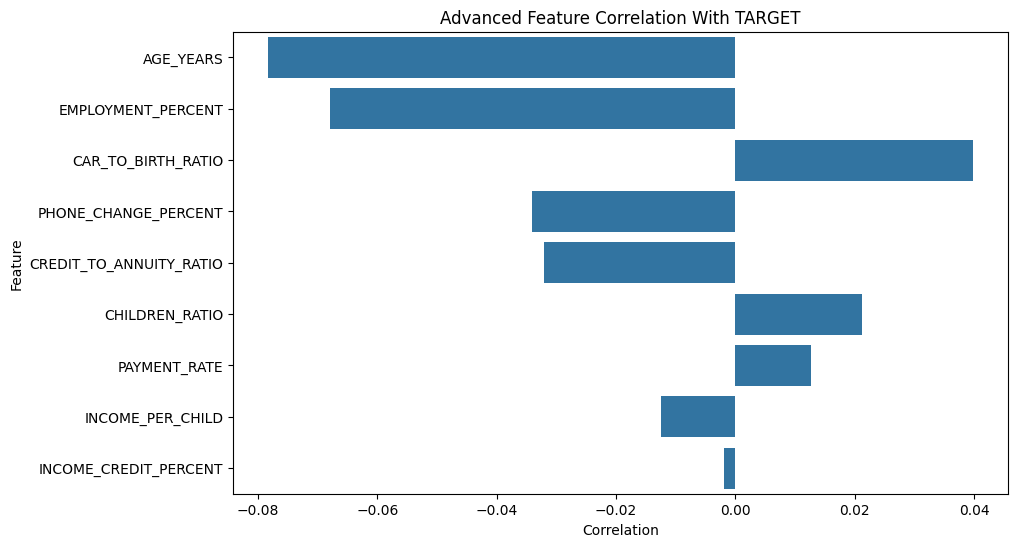

,Correlation
AGE_YEARS,-0.078239
EMPLOYMENT_PERCENT,-0.067955
CAR_TO_BIRTH_RATIO,0.039817
PHONE_CHANGE_PERCENT,-0.033991
CREDIT_TO_ANNUITY_RATIO,-0.032101
CHILDREN_RATIO,0.021224
PAYMENT_RATE,0.012698
INCOME_PER_CHILD,-0.012529
INCOME_CREDIT_PERCENT,-0.001817


In [40]:
# ==========================================================
# Correlation of V2 Features With TARGET
# ==========================================================

new_v2_features = [
    "AGE_YEARS",
    "EMPLOYMENT_PERCENT",
    "CREDIT_TO_ANNUITY_RATIO",
    "PAYMENT_RATE",
    "INCOME_CREDIT_PERCENT",
    "CHILDREN_RATIO",
    "INCOME_PER_CHILD",
    "CAR_TO_BIRTH_RATIO",
    "PHONE_CHANGE_PERCENT"
]

v2_corr = (
    train_df[
        new_v2_features + ["TARGET"]
    ]
    .corr()["TARGET"]
    .drop("TARGET")
    .sort_values(
        key=abs,
        ascending=False
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=v2_corr.values,
    y=v2_corr.index
)

plt.title(
    "Advanced Feature Correlation With TARGET"
)

plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

display(
    v2_corr.to_frame(
        name="Correlation"
    )
)

# 🚀 LightGBM After Advanced Feature Engineering (V2)

The dataset has been enhanced using advanced business-driven feature engineering.

Before moving into hyperparameter tuning or ensemble strategies, the first objective is to measure whether these newly engineered features improve model performance.

The same LightGBM baseline configuration is retrained to isolate the impact of feature engineering alone.

This helps answer:

> Did V2 feature engineering improve predictive power?

In [41]:
# ==========================================================
# LightGBM After Advanced Feature Engineering (V2)
# ==========================================================

lgb_v2 = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train
lgb_v2.fit(
    X_train,
    y_train
)

# Predict probabilities
y_valid_proba_v2 = lgb_v2.predict_proba(
    X_valid
)[:, 1]

# ROC-AUC
roc_auc_v2 = roc_auc_score(
    y_valid,
    y_valid_proba_v2
)

print("=" * 60)
print("LightGBM After Advanced FE V2")
print("=" * 60)
print(f"ROC-AUC Score: {roc_auc_v2:.4f}")

print("\nImprovement Over Baseline:")
print(
    f"{roc_auc_v2 - roc_auc_lgb:+.4f}"
)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.093593 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12902
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 239
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

# 📌 Model Benchmark Summary

Several tree-based models and optimization strategies were evaluated
using the engineered `application_train.csv` dataset.

### Model Performance Summary

| Model | ROC-AUC |
|--------|----------|
| Logistic Regression | 0.6131 |
| LightGBM Baseline | 0.7623 |
| Tuned LightGBM V1 | 0.7632 |
| Tuned LightGBM V2 | 0.7621 |
| XGBoost Baseline | 0.7614 |
| Tuned XGBoost | 0.7625 |
| CatBoost Baseline | 0.7606 |
| Ensemble Model | 0.7629 |

### Key Findings

- Tree-based boosting models significantly outperformed Logistic Regression.
- Performance plateaued around **0.762 – 0.763 ROC-AUC**.
- Feature engineering provided limited gains.
- Threshold optimization improved classification quality (F1-score) rather than ROC-AUC.
- Further improvement is likely to come from **external relational datasets** rather than model tuning.

At this stage, the next priority becomes:

> **Feature aggregation from external datasets (bureau, previous applications, installments, credit history).**

# 🏦 Bureau Dataset Aggregation

The `bureau.csv` dataset contains historical credit information
for each client from external financial institutions.

Since a single client may have multiple bureau records,
the dataset must be aggregated to the client level.

The objective is to create credit-history features that summarize:

- Number of previous credits
- Active credit exposure
- Outstanding debt
- Overdue behavior
- Historical borrowing activity

These aggregated features will later be merged into the main application dataset.

In [42]:
# ==========================================================
# Load Bureau Dataset
# ==========================================================

bureau = pd.read_csv(r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\bureau.csv")

print("=" * 60)
print("Bureau Shape")
print("=" * 60)

print(bureau.shape)

display(
    bureau.head()
)

Bureau Shape
(1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [43]:
print("=" * 60)
print("Column Names")
print("=" * 60)
for col in bureau.columns:
    print(col)

Column Names
SK_ID_CURR
SK_ID_BUREAU
CREDIT_ACTIVE
CREDIT_CURRENCY
DAYS_CREDIT
CREDIT_DAY_OVERDUE
DAYS_CREDIT_ENDDATE
DAYS_ENDDATE_FACT
AMT_CREDIT_MAX_OVERDUE
CNT_CREDIT_PROLONG
AMT_CREDIT_SUM
AMT_CREDIT_SUM_DEBT
AMT_CREDIT_SUM_LIMIT
AMT_CREDIT_SUM_OVERDUE
CREDIT_TYPE
DAYS_CREDIT_UPDATE
AMT_ANNUITY


## 🏦 Bureau Feature Aggregation

The bureau dataset contains historical credit records from external financial institutions.

To make this information usable for machine learning, all bureau records are aggregated at the client level.

The generated features summarize:

- Credit history volume
- Debt exposure
- Overdue behavior
- Credit activity
- Historical borrowing patterns

These features introduce external credit-history information that is not available in the main application dataset.

In [44]:
# ==========================================================
# Bureau Aggregation
# ==========================================================

bureau_agg = bureau.groupby(
    'SK_ID_CURR'
).agg({

    # Counts
    'SK_ID_BUREAU': ['count'],

    # Credit history
    'DAYS_CREDIT': [
        'mean',
        'min',
        'max'
    ],

    # Overdue
    'CREDIT_DAY_OVERDUE': [
        'mean',
        'max'
    ],

    # Credit amount
    'AMT_CREDIT_SUM': [
        'mean',
        'sum',
        'max'
    ],

    # Debt
    'AMT_CREDIT_SUM_DEBT': [
        'mean',
        'sum',
        'max'
    ],

    # Overdue amount
    'AMT_CREDIT_SUM_OVERDUE': [
        'mean',
        'sum',
        'max'
    ],

    # Credit limit
    'AMT_CREDIT_SUM_LIMIT': [
        'mean',
        'sum'
    ],

    # Prolongations
    'CNT_CREDIT_PROLONG': [
        'sum',
        'max'
    ]

})

# Flatten MultiIndex columns
bureau_agg.columns = [
    f'BUREAU_{col}_{agg}'
    for col, agg in bureau_agg.columns
]

bureau_agg.reset_index(
    inplace=True
)

print("=" * 60)
print("Bureau Aggregated Shape")
print("=" * 60)

print(bureau_agg.shape)

display(
    bureau_agg.head()
)

Bureau Aggregated Shape
(305811, 20)


,SK_ID_CURR,BUREAU_SK_ID_BUREAU_count,BUREAU_DAYS_CREDIT_mean,BUREAU_DAYS_CREDIT_min,BUREAU_DAYS_CREDIT_max,BUREAU_CREDIT_DAY_OVERDUE_mean,BUREAU_CREDIT_DAY_OVERDUE_max,BUREAU_AMT_CREDIT_SUM_mean,BUREAU_AMT_CREDIT_SUM_sum,BUREAU_AMT_CREDIT_SUM_max,BUREAU_AMT_CREDIT_SUM_DEBT_mean,BUREAU_AMT_CREDIT_SUM_DEBT_sum,BUREAU_AMT_CREDIT_SUM_DEBT_max,BUREAU_AMT_CREDIT_SUM_OVERDUE_mean,BUREAU_AMT_CREDIT_SUM_OVERDUE_sum,BUREAU_AMT_CREDIT_SUM_OVERDUE_max,BUREAU_AMT_CREDIT_SUM_LIMIT_mean,BUREAU_AMT_CREDIT_SUM_LIMIT_sum,BUREAU_CNT_CREDIT_PROLONG_sum,BUREAU_CNT_CREDIT_PROLONG_max
0,100001,7,-735.000000,-1572,-49,0.0,0,207623.571429,1453365.000,378000.0,85240.928571,596686.5,373239.0,0.0,0.0,0.0,0.00000,0.000,0,0
1,100002,8,-874.000000,-1437,-103,0.0,0,108131.945625,865055.565,450000.0,49156.200000,245781.0,245781.0,0.0,0.0,0.0,7997.14125,31988.565,0,0
2,100003,4,-1400.750000,-2586,-606,0.0,0,254350.125000,1017400.500,810000.0,0.000000,0.0,0.0,0.0,0.0,0.0,202500.00000,810000.000,0,0
3,100004,2,-867.000000,-1326,-408,0.0,0,94518.900000,189037.800,94537.8,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000,0.000,0,0
4,100005,3,-190.666667,-373,-62,0.0,0,219042.000000,657126.000,568800.0,189469.500000,568408.5,543087.0,0.0,0.0,0.0,0.00000,0.000,0,0


### 📊 Bureau Aggregation Results

The bureau dataset was successfully transformed from a transactional credit-history table into a client-level feature table.

### Before Aggregation

- Rows: 1,716,428
- Columns: 17

### After Aggregation

- Rows: 305,811
- Features: 20

### Key Observation

Each client now has a single summarized credit-history profile containing:

- Historical credit volume
- Debt exposure
- Overdue behavior
- Credit utilization patterns
- Borrowing history statistics

These features can now be merged directly into the main application dataset.

## 🔗 Bureau Features Integration

In [45]:
# ==========================================================
# Merge Bureau Features
# ==========================================================

train_df = train_df.merge(
    bureau_agg,
    on='SK_ID_CURR',
    how='left'
)

test_df = test_df.merge(
    bureau_agg,
    on='SK_ID_CURR',
    how='left'
)

print("=" * 60)
print("After Bureau Merge")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

After Bureau Merge
Train Shape: (307511, 155)
Test Shape : (48744, 154)


### 🔗 Bureau Features Integration

The aggregated bureau features were merged into the main application dataset.

### Dataset Growth

| Dataset | Before Merge | After Merge |
|----------|-------------|-------------|
| Train | 136 Features | 155 Features |
| Test | 135 Features | 154 Features |

### New Information Added

The bureau dataset contributes external credit-history information that is not available in the application dataset, including:

- Historical borrowing activity
- Outstanding debt statistics
- Credit utilization patterns
- Overdue behavior
- Credit history duration

These features are expected to provide stronger predictive signals than application-based feature engineering alone.

## 🧹 Bureau Missing Value Handling

In [46]:
# ==========================================================
# Missing Values After Bureau Merge
# ==========================================================

train_missing = (
    train_df
    .isnull()
    .sum()
    .sum()
)

test_missing = (
    test_df
    .isnull()
    .sum()
    .sum()
)

print("=" * 60)
print("Missing Values After Bureau Merge")
print("=" * 60)

print("Train Missing:", train_missing)
print("Test Missing :", test_missing)

Missing Values After Bureau Merge
Train Missing: 982899
Test Missing : 146889


### 🧹 Bureau Missing Value Handling

After merging bureau features, missing values were introduced for clients without external credit-history records.

These missing values do not represent data quality issues.

Instead, they indicate:

> No bureau history available for the client.

For aggregated bureau features, missing values are replaced with zero because:

- No previous credits → 0
- No debt → 0
- No overdue amount → 0
- No credit history statistics available

This preserves the information that the client has no external credit record while keeping the dataset model-ready.

In [47]:
# ==========================================================
# Fill Bureau Missing Values
# ==========================================================

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print("=" * 60)
print("Missing Values After Fill")
print("=" * 60)

print(
    "Train Missing:",
    train_df.isnull().sum().sum()
)

print(
    "Test Missing:",
    test_df.isnull().sum().sum()
)

Missing Values After Fill
Train Missing: 0
Test Missing: 0


# 🔄 Re-Encoding After Bureau Integration

The bureau features were merged into the original application dataset.

Since the merged dataset still contains categorical variables,
encoding must be applied again before training machine learning models.

This ensures that both:

- Original application features
- Bureau aggregated features

are included in the final modeling dataset.

In [48]:
# ==========================================================
# One-Hot Encoding After Bureau Merge
# ==========================================================

train_df = pd.get_dummies(
    train_df,
    drop_first=True
)

test_df = pd.get_dummies(
    test_df,
    drop_first=True
)

# Align columns
train_df, test_df = train_df.align(
    test_df,
    join='left',
    axis=1,
    fill_value=0
)

print("=" * 60)
print("After Encoding + Bureau")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

After Encoding + Bureau
Train Shape: (307511, 263)
Test Shape : (48744, 263)


## 🏦 Bureau Integration Summary

External credit-history information was successfully merged into the application dataset.

### Feature Growth

| Stage | Features |
|---------|---------|
| Application Dataset Only | 251 |
| After Bureau Integration | 263 |

### Impact

The bureau dataset introduced external credit-history signals including:

- Historical borrowing activity
- Outstanding debt information
- Credit utilization statistics
- Overdue behavior
- Credit history duration

These features provide information that is unavailable in the original application dataset and are expected to improve model performance.

# 🧹 Feature Name Cleanup

Some engineered feature names contain special characters that are not supported by LightGBM.

All feature names are standardized by replacing special symbols with underscores while preserving the underlying feature values.


In [49]:
bad_cols = [
    col for col in X_train.columns
    if any(
        ch in str(col)
        for ch in ['[', ']', '{', '}', ':', '"', ',', '%']
    )
]

print(len(bad_cols))
print(bad_cols[:50])

0
[]


In [50]:
import re

X_train.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', str(col))
    for col in X_train.columns
]

X_valid.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', str(col))
    for col in X_valid.columns
]

test_df.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', str(col))
    for col in test_df.columns
]

In [51]:
print(X_train.shape)
print(X_valid.shape)

(246008, 250)
(61503, 250)


# 🚀 LightGBM With Bureau Features

The model is retrained using the enriched dataset containing both:

- Application features
- Bureau credit-history features

The objective is to evaluate whether external credit information improves predictive performance beyond the application dataset alone.

In [52]:
# ==========================================================
# Prepare Data
# ==========================================================

from sklearn.model_selection import train_test_split

X = train_df.drop(
    columns=['TARGET']
)

y = train_df['TARGET']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("=" * 60)
print("Train Validation Split")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

Train Validation Split
X_train: (246008, 262)
X_valid: (61503, 262)


In [53]:
bad_cols = [
    col for col in X_train.columns
    if not str(col).replace('_', '').isalnum()
]

print(len(bad_cols))
print(bad_cols[:30])

65
['NAME_CONTRACT_TYPE_Revolving loans', 'NAME_TYPE_SUITE_Group of people', 'NAME_TYPE_SUITE_Spouse, partner', 'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Maternity leave', 'NAME_INCOME_TYPE_State servant', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Single / not married', 'NAME_HOUSING_TYPE_House / apartment', 'NAME_HOUSING_TYPE_Municipal apartment', 'NAME_HOUSING_TYPE_Office apartment', 'NAME_HOUSING_TYPE_Rented apartment', 'NAME_HOUSING_TYPE_With parents', 'OCCUPATION_TYPE_Cleaning staff', 'OCCUPATION_TYPE_Cooking staff', 'OCCUPATION_TYPE_Core staff', 'OCCUPATION_TYPE_HR staff', 'OCCUPATION_TYPE_High skill tech staff', 'OCCUPATION_TYPE_IT staff', 'OCCUPATION_TYPE_Low-skill Laborers', 'OCCUPATION_TYPE_Medicine staff', 'OCCUPATION_TYPE_Private service staff', 'OCCUPATION_TYPE_Realty agents', 'OCCUPATION_TYPE_Sales staff', 

In [54]:
print(X_train.columns[:20].tolist())

['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT']


In [55]:
print(X_train.columns.duplicated().sum())

0


In [56]:
import re

def clean_columns(df):
    df = df.copy()

    df.columns = [
        re.sub(r'[^A-Za-z0-9]+', '_', str(col))
        for col in df.columns
    ]

    return df

X_train = clean_columns(X_train)
X_valid = clean_columns(X_valid)
test_df = clean_columns(test_df)

print("Duplicates:", X_train.columns.duplicated().sum())

Duplicates: 0


In [57]:
# ==========================================================
# LightGBM + Bureau Features
# ==========================================================

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

lgb_bureau = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_bureau.fit(
    X_train,
    y_train
)

y_valid_proba_bureau = lgb_bureau.predict_proba(
    X_valid
)[:, 1]

roc_auc_bureau = roc_auc_score(
    y_valid,
    y_valid_proba_bureau
)

print("=" * 60)
print("LightGBM + Bureau Features")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc_bureau:.4f}")

print("\nComparison")
print("Previous Best : 0.7632")
print(f"Current Model : {roc_auc_bureau:.4f}")
print(f"Improvement   : {roc_auc_bureau - 0.7632:+.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.097237 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19077
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 252
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

## 🚀 Bureau Features Impact Analysis

The integration of external credit-history information produced the largest performance improvement observed so far.

## Results

| Model | ROC-AUC |
|---------|---------|
| Best Previous LightGBM | 0.7632 |
| LightGBM + Bureau Features | 0.7720 |

### Improvement

+0.0088 ROC-AUC

## Key Insight

Most previous improvements from feature engineering, model tuning, and ensemble methods were relatively small.

The bureau dataset introduced entirely new information about historical credit behavior, debt exposure, and borrowing patterns.

This confirms that external credit-history features provide substantially more predictive value than additional transformations of application data alone.

## Conclusion

Bureau information is currently the strongest feature source in the project and establishes a new performance baseline for future experiments.

# 📊 Bureau Balance

In [58]:
bureau_balance = pd.read_csv(r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\bureau_balance.csv")

In [59]:
print(bureau_balance.shape)
print(bureau_balance.columns.tolist())

bureau_balance.head()

(27299925, 3)
['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [60]:
bureau_balance.shape
bureau_balance.head()
bureau_balance.columns

Index(['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS'], dtype='str')

## 📊 Bureau Balance Overview

The bureau_balance dataset contains monthly historical status information for each credit record.

Unlike the bureau dataset, which provides aggregated credit information, bureau_balance captures monthly repayment behavior and delinquency history.

This dataset is expected to provide highly predictive behavioral features related to payment risk and credit quality.

In [61]:
# ==========================================================
# STATUS Distribution
# ==========================================================

status_counts = (
    bureau_balance['STATUS']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("=" * 60)
print("STATUS Distribution (%)")
print("=" * 60)

display(
    status_counts
)

STATUS Distribution (%)


STATUS
0    27.470797
1     0.887720
2     0.085784
3     0.032689
4     0.021418
5     0.228594
C    49.989123
X    21.283875
Name: proportion, dtype: float64

## 🚨 Worst Delinquency Feature

The most severe delinquency status observed during the lifetime of a credit account is extracted.

This feature captures the maximum repayment risk associated with each loan and provides a strong signal of historical credit behavior.

Higher values indicate more severe payment delays.

In [62]:
# ==========================================================
# Worst Delinquency Per Loan
# ==========================================================

status_mapping = {
    'X': -1,
    'C': 0,
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5
}

bureau_balance['STATUS_NUM'] = (
    bureau_balance['STATUS']
    .map(status_mapping)
)

worst_status = (
    bureau_balance
    .groupby('SK_ID_BUREAU')['STATUS_NUM']
    .max()
    .reset_index()
)

worst_status.rename(
    columns={
        'STATUS_NUM': 'WORST_STATUS'
    },
    inplace=True
)

print("=" * 60)
print("Worst Status Shape")
print("=" * 60)

print(worst_status.shape)

display(
    worst_status.head()
)

Worst Status Shape
(817395, 2)


,SK_ID_BUREAU,WORST_STATUS
0,5001709,0
1,5001710,0
2,5001711,0
3,5001712,0
4,5001713,-1


## 📅 Delinquent Months Feature

In addition to the maximum delinquency severity, the total number of delinquent months is calculated.

This feature captures the persistence of repayment problems rather than a single extreme event.

Clients with repeated delinquency episodes are generally associated with higher credit risk.

In [63]:
# ==========================================================
# Number Of Delinquent Months
# ==========================================================

delinquent_months = (
    bureau_balance
    .assign(
        DELINQUENT=lambda x:
        x['STATUS'].isin(
            ['1', '2', '3', '4', '5']
        ).astype(int)
    )
    .groupby('SK_ID_BUREAU')['DELINQUENT']
    .sum()
    .reset_index()
)

delinquent_months.rename(
    columns={
        'DELINQUENT':
        'DELINQUENT_MONTHS'
    },
    inplace=True
)

print("=" * 60)
print("Delinquent Months Shape")
print("=" * 60)

print(delinquent_months.shape)

display(
    delinquent_months.head()
)

Delinquent Months Shape
(817395, 2)


,SK_ID_BUREAU,DELINQUENT_MONTHS
0,5001709,0
1,5001710,0
2,5001711,0
3,5001712,0
4,5001713,0


# 🔗 Bureau Balance Integration

The behavioral features extracted from bureau_balance are merged with bureau records.

This allows monthly repayment behavior to be connected to individual clients through the bureau credit-history table.

The resulting features combine:

- Credit history information
- Debt statistics
- Delinquency behavior
- Monthly repayment patterns

In [64]:
# ==========================================================
# Merge Bureau Balance Features
# ==========================================================

bureau_bb = bureau[
    ['SK_ID_BUREAU', 'SK_ID_CURR']
].copy()

bureau_bb = bureau_bb.merge(
    worst_status,
    on='SK_ID_BUREAU',
    how='left'
)

bureau_bb = bureau_bb.merge(
    delinquent_months,
    on='SK_ID_BUREAU',
    how='left'
)

print("=" * 60)
print("Merged Bureau Balance Shape")
print("=" * 60)

print(bureau_bb.shape)

display(
    bureau_bb.head()
)

Merged Bureau Balance Shape
(1716428, 4)


,SK_ID_BUREAU,SK_ID_CURR,WORST_STATUS,DELINQUENT_MONTHS
0,5714462,215354,NaN,NaN
1,5714463,215354,NaN,NaN
2,5714464,215354,NaN,NaN
3,5714465,215354,NaN,NaN
4,5714466,215354,NaN,NaN


In [65]:
# ==========================================================
# Aggregate To Client Level
# ==========================================================

bureau_balance_agg = (
    bureau_bb
    .groupby('SK_ID_CURR')
    .agg({

        'WORST_STATUS': [
            'max',
            'mean'
        ],

        'DELINQUENT_MONTHS': [
            'sum',
            'mean',
            'max'
        ]

    })
)

bureau_balance_agg.columns = [

    'BB_WORST_STATUS_MAX',
    'BB_WORST_STATUS_MEAN',

    'BB_DELINQ_SUM',
    'BB_DELINQ_MEAN',
    'BB_DELINQ_MAX'

]

bureau_balance_agg = (
    bureau_balance_agg
    .reset_index()
)

print("=" * 60)
print("Bureau Balance Aggregated Shape")
print("=" * 60)

print(bureau_balance_agg.shape)

display(
    bureau_balance_agg.head()
)

Bureau Balance Aggregated Shape
(305811, 6)


,SK_ID_CURR,BB_WORST_STATUS_MAX,BB_WORST_STATUS_MEAN,BB_DELINQ_SUM,BB_DELINQ_MEAN,BB_DELINQ_MAX
0,100001,1.0,0.142857,1.0,0.142857,1.0
1,100002,1.0,0.750000,27.0,3.375000,6.0
2,100003,NaN,NaN,0.0,NaN,NaN
3,100004,NaN,NaN,0.0,NaN,NaN
4,100005,0.0,0.000000,0.0,0.000000,0.0


## 📈 Bureau Balance Behavioral Features

Monthly repayment behavior was aggregated from bureau_balance and transformed into client-level features.

The generated features capture:

- Maximum delinquency severity
- Average delinquency severity
- Total delinquent months
- Average delinquent months
- Maximum delinquent months

These features provide behavioral information that complements traditional credit-history statistics from the bureau dataset.

In [66]:
# ==========================================================
# Merge Bureau Balance Features
# ==========================================================

train_df = train_df.merge(
    bureau_balance_agg,
    on='SK_ID_CURR',
    how='left'
)

test_df = test_df.merge(
    bureau_balance_agg,
    on='SK_ID_CURR',
    how='left'
)

print("=" * 60)
print("After Bureau Balance Merge")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

After Bureau Balance Merge
Train Shape: (307511, 268)
Test Shape : (48744, 268)


In [67]:
# Fill Missing Values

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print(
    train_df.isnull().sum().sum()
)

print(
    test_df.isnull().sum().sum()
)

0
0


# 🚀 LightGBM With Bureau Balance Features

The dataset now combines:

- Application data
- Engineered features
- Bureau credit-history features
- Bureau balance behavioral features

This represents the richest feature set constructed so far.

The objective is to measure the incremental value of monthly repayment behavior on default prediction performance.

In [68]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['TARGET'])
y = train_df['TARGET']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_valid.shape)

(246008, 267)
(61503, 267)


In [69]:
import re

def clean_columns(df):
    df = df.copy()

    df.columns = [
        re.sub(r'[^A-Za-z0-9]+', '_', str(col))
        for col in df.columns
    ]

    return df

X_train = clean_columns(X_train)
X_valid = clean_columns(X_valid)

In [70]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

lgb_final = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_final.fit(
    X_train,
    y_train
)

y_valid_proba = lgb_final.predict_proba(
    X_valid
)[:, 1]

roc_auc = roc_auc_score(
    y_valid,
    y_valid_proba
)

print("=" * 60)
print("LightGBM + Bureau + Bureau Balance")
print("=" * 60)
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\nPrevious Best: 0.7720")
print(f"Current Score: {roc_auc:.4f}")
print(f"Improvement  : {roc_auc - 0.7720:+.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.086846 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19741
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 257
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

#3 📊 Bureau Balance Evaluation

Behavioral features extracted from bureau_balance were added to the existing Bureau-enhanced dataset.

## Results

| Model | ROC-AUC |
|---------|---------|
| LightGBM + Bureau Features | 0.7720 |
| LightGBM + Bureau Balance Features | 0.7718 |

### Observation

The addition of the current bureau_balance features did not improve model performance.

### Interpretation

The extracted behavioral features appear to provide limited incremental information beyond the existing bureau credit-history features.

This suggests that the Bureau dataset already captures most of the predictive signal associated with historical credit behavior.

### Decision

Further optimization of bureau_balance features is deferred in favor of exploring higher-impact external datasets.

# 📊 Previous Application

In [71]:
previous_application = pd.read_csv(r'C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\previous_application.csv')

print(previous_application.shape)
print(previous_application.columns.tolist())
print(previous_application.head())


(1670214, 37)
['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']
   SK_ID_PREV  SK_ID_CURR NAME_CONTRACT_TYPE  AMT_ANNUITY  AMT_APPLICATION  \
0     2030495      271877     Consumer loans     1730.430          17145.0   
1     2802425      108129         Cash l

## 📊 Previous Application Status Analysis

The first step is to analyze the outcomes of previous applications.

This helps determine whether historical approval and rejection patterns are associated with future default risk.

In [72]:
print("=" * 60)
print("Contract Status Distribution")
print("=" * 60)

status_dist = (
    previous_application['NAME_CONTRACT_STATUS']
    .value_counts(normalize=True)
    * 100
)

display(status_dist)

Contract Status Distribution


NAME_CONTRACT_STATUS
Approved        62.074740
Canceled        18.938831
Refused         17.403638
Unused offer     1.582791
Name: proportion, dtype: float64

In [73]:
print("=" * 60)
print("Contract Type Distribution")
print("=" * 60)

contract_type_dist = (
    previous_application['NAME_CONTRACT_TYPE']
    .value_counts(normalize=True)
    * 100
)

display(contract_type_dist)

Contract Type Distribution


NAME_CONTRACT_TYPE
Cash loans         44.757917
Consumer loans     43.656142
Revolving loans    11.565225
XNA                 0.020716
Name: proportion, dtype: float64

# 📈 Previous Application History Features

Historical application behavior is aggregated at the client level.

The generated features capture:

- Number of previous applications
- Number of approved applications
- Number of refused applications
- Number of canceled applications
- Approval ratio
- Refusal ratio

These features summarize the client's historical interaction with the lending institution.

In [74]:
# ==========================================================
# Previous Application Aggregation V1
# ==========================================================

prev_agg = (
    previous_application
    .groupby('SK_ID_CURR')
    .agg({

        'SK_ID_PREV': 'count'

    })
    .rename(
        columns={
            'SK_ID_PREV': 'PREV_APP_COUNT'
        }
    )
)

# Approved
approved = (
    previous_application
    .groupby('SK_ID_CURR')['NAME_CONTRACT_STATUS']
    .apply(lambda x: (x == 'Approved').sum())
)

# Refused
refused = (
    previous_application
    .groupby('SK_ID_CURR')['NAME_CONTRACT_STATUS']
    .apply(lambda x: (x == 'Refused').sum())
)

# Canceled
canceled = (
    previous_application
    .groupby('SK_ID_CURR')['NAME_CONTRACT_STATUS']
    .apply(lambda x: (x == 'Canceled').sum())
)

prev_agg['PREV_APPROVED_COUNT'] = approved
prev_agg['PREV_REFUSED_COUNT'] = refused
prev_agg['PREV_CANCELED_COUNT'] = canceled

prev_agg['PREV_APPROVAL_RATIO'] = (
    prev_agg['PREV_APPROVED_COUNT']
    /
    prev_agg['PREV_APP_COUNT']
)

prev_agg['PREV_REFUSAL_RATIO'] = (
    prev_agg['PREV_REFUSED_COUNT']
    /
    prev_agg['PREV_APP_COUNT']
)

prev_agg = prev_agg.reset_index()

print("=" * 60)
print("Previous Application Aggregation")
print("=" * 60)

print(prev_agg.shape)

display(prev_agg.head())

Previous Application Aggregation
(338857, 7)


,SK_ID_CURR,PREV_APP_COUNT,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT,PREV_CANCELED_COUNT,PREV_APPROVAL_RATIO,PREV_REFUSAL_RATIO
0,100001,1,1,0,0,1.0,0.0
1,100002,1,1,0,0,1.0,0.0
2,100003,3,3,0,0,1.0,0.0
3,100004,1,1,0,0,1.0,0.0
4,100005,2,1,0,1,0.5,0.0


## 🚀 Previous Application Features

Client-level historical application statistics were extracted from previous_application.

The generated features summarize:

- Application frequency
- Approval history
- Refusal history
- Cancellation history
- Approval rate
- Refusal rate

These features capture the client's historical relationship with the lender and may provide predictive information beyond external credit-history records.

In [75]:
# ==========================================================
# Merge Previous Application Features
# ==========================================================

train_df = train_df.merge(
    prev_agg,
    on='SK_ID_CURR',
    how='left'
)

test_df = test_df.merge(
    prev_agg,
    on='SK_ID_CURR',
    how='left'
)

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print("=" * 60)
print("After Previous Application Merge")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

After Previous Application Merge
Train Shape: (307511, 274)
Test Shape : (48744, 274)


# 🚀 LightGBM With Previous Application Features

Historical application behavior was added to the existing feature set.

The model now combines:

- Application data
- Feature engineering features
- Bureau credit-history features
- Previous application history

This experiment evaluates whether internal application history provides additional predictive value beyond external credit information.

In [76]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['TARGET'])
y = train_df['TARGET']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_valid.shape)

(246008, 273)
(61503, 273)


In [77]:
import re

def clean_columns(df):
    df = df.copy()

    df.columns = [
        re.sub(r'[^A-Za-z0-9]+', '_', str(col))
        for col in df.columns
    ]

    return df

X_train = clean_columns(X_train)
X_valid = clean_columns(X_valid)

In [78]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

lgb_prev = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_prev.fit(
    X_train,
    y_train
)

y_valid_proba = lgb_prev.predict_proba(
    X_valid
)[:, 1]

roc_auc_prev = roc_auc_score(
    y_valid,
    y_valid_proba
)

print("=" * 60)
print("LightGBM + Bureau + Previous Applications")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc_prev:.4f}")

print("\nComparison")
print("Best Bureau Model : 0.7720")
print(f"Current Model     : {roc_auc_prev:.4f}")
print(f"Improvement       : {roc_auc_prev - 0.7720:+.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.091751 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20169
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 263
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

## 📊 Previous Application Evaluation

Historical application features provided additional predictive value beyond bureau credit-history information.

## Results

| Model | ROC-AUC |
|---------|---------|
| LightGBM + Bureau | 0.7720 |
| LightGBM + Bureau + Previous Applications | 0.7739 |

### Improvement

+0.0019 ROC-AUC

### Interpretation

Previous application behavior contains useful information regarding a client's historical interaction with the lender.

Application frequency, approval history, refusal history, and cancellation behavior contribute additional predictive signal beyond external credit-history records.

### Current Best Model

LightGBM + Bureau + Previous Applications

ROC-AUC = 0.7739

# 🚀 Previous Application Feature Engineering V2

The second feature engineering stage focuses on the numerical characteristics of previous applications.

The generated features capture:

- Historical credit amounts
- Application amounts
- Payment durations
- Recency of previous applications

These features provide additional information about borrowing behavior and lending history.

In [79]:
# ==========================================================
# Previous Application Aggregation V2
# ==========================================================

prev_numeric_agg = (
    previous_application
    .groupby('SK_ID_CURR')
    .agg({

        'AMT_CREDIT': [
            'mean',
            'max'
        ],

        'AMT_APPLICATION': [
            'mean',
            'max'
        ],

        'CNT_PAYMENT': [
            'mean',
            'max'
        ],

        'DAYS_DECISION': [
            'mean',
            'max'
        ]

    })
)

prev_numeric_agg.columns = [

    'PREV_AMT_CREDIT_MEAN',
    'PREV_AMT_CREDIT_MAX',

    'PREV_AMT_APPLICATION_MEAN',
    'PREV_AMT_APPLICATION_MAX',

    'PREV_CNT_PAYMENT_MEAN',
    'PREV_CNT_PAYMENT_MAX',

    'PREV_DAYS_DECISION_MEAN',
    'PREV_DAYS_DECISION_MAX'

]

prev_numeric_agg = (
    prev_numeric_agg
    .reset_index()
)

print("=" * 60)
print("Previous Application V2")
print("=" * 60)

print(prev_numeric_agg.shape)

display(
    prev_numeric_agg.head()
)

Previous Application V2
(338857, 9)


,SK_ID_CURR,PREV_AMT_CREDIT_MEAN,PREV_AMT_CREDIT_MAX,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_CNT_PAYMENT_MEAN,PREV_CNT_PAYMENT_MAX,PREV_DAYS_DECISION_MEAN,PREV_DAYS_DECISION_MAX
0,100001,23787.00,23787.0,24835.50,24835.5,8.0,8.0,-1740.0,-1740
1,100002,179055.00,179055.0,179055.00,179055.0,24.0,24.0,-606.0,-606
2,100003,484191.00,1035882.0,435436.50,900000.0,10.0,12.0,-1305.0,-746
3,100004,20106.00,20106.0,24282.00,24282.0,4.0,4.0,-815.0,-815
4,100005,20076.75,40153.5,22308.75,44617.5,12.0,12.0,-536.0,-315


## 🚀 Previous Application Feature Engineering V2 Evaluation

Numerical aggregates were extracted from previous applications.

The generated features summarize:

- Historical credit amounts
- Application amounts
- Payment durations
- Recency of previous applications

These features provide a quantitative view of the client's historical borrowing behavior.

In [80]:
# ==========================================================
# Merge Previous Application V2
# ==========================================================

train_df = train_df.merge(
    prev_numeric_agg,
    on='SK_ID_CURR',
    how='left'
)

test_df = test_df.merge(
    prev_numeric_agg,
    on='SK_ID_CURR',
    how='left'
)

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print("=" * 60)
print("After Previous Application V2 Merge")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

After Previous Application V2 Merge
Train Shape: (307511, 282)
Test Shape : (48744, 282)


# 🚀 LightGBM With Previous Application V2 Features

The feature set has been expanded with numerical aggregates extracted from previous applications.

New information includes:

- Historical credit amounts
- Application amounts
- Payment duration statistics
- Previous application recency

The objective is to evaluate whether quantitative borrowing behavior improves predictive performance beyond approval and refusal history alone.

In [81]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['TARGET'])
y = train_df['TARGET']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [82]:
import re

def clean_columns(df):
    df = df.copy()

    df.columns = [
        re.sub(r'[^A-Za-z0-9]+', '_', str(col))
        for col in df.columns
    ]

    return df

X_train = clean_columns(X_train)
X_valid = clean_columns(X_valid)

In [83]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

lgb_prev_v2 = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_prev_v2.fit(
    X_train,
    y_train
)

y_valid_proba = lgb_prev_v2.predict_proba(
    X_valid
)[:, 1]

roc_auc_prev_v2 = roc_auc_score(
    y_valid,
    y_valid_proba
)

print("=" * 60)
print("LightGBM + Previous Application V2")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc_prev_v2:.4f}")

print("\nComparison")
print("Previous Best : 0.7739")
print(f"Current Model : {roc_auc_prev_v2:.4f}")
print(f"Improvement   : {roc_auc_prev_v2 - 0.7739:+.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.106785 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21977
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 271
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM + Previous Application V2
ROC-AUC Score: 0.7770

Comparison
Previous Best : 0.7739
Current Model : 0.7770
Improvement 

# 🏆 Current Best Model

## Feature Sources

- Application data
- Engineered application features
- Bureau credit-history features
- Previous application history features

## Best Performance

ROC-AUC = 0.7770

## Performance Progression

| Model | ROC-AUC |
|---------|---------|
| Logistic Regression | 0.6131 |
| LightGBM Baseline | 0.7623 |
| Tuned LightGBM | 0.7632 |
| LightGBM + Bureau | 0.7720 |
| LightGBM + Previous Application V1 | 0.7739 |
| LightGBM + Previous Application V2 | 0.7770 |

## Observation

Previous application features provide substantial predictive value and currently represent the strongest source of performance improvement after bureau credit-history features.

# 🚀 Previous Application Feature Engineering V3

The third feature engineering stage focuses on application outcomes.

Instead of aggregating all historical applications together, approved and refused applications are analyzed separately.

This allows the model to distinguish between successful and unsuccessful borrowing behavior.

In [84]:
# ==========================================================
# Approved Applications
# ==========================================================

approved_apps = previous_application[
    previous_application['NAME_CONTRACT_STATUS'] == 'Approved'
].copy()

approved_agg = (
    approved_apps
    .groupby('SK_ID_CURR')
    .agg({

        'AMT_CREDIT': [
            'mean',
            'max'
        ],

        'CNT_PAYMENT': [
            'mean',
            'max'
        ],

        'DAYS_DECISION': [
            'max'
        ]

    })
)

approved_agg.columns = [

    'APPROVED_CREDIT_MEAN',
    'APPROVED_CREDIT_MAX',

    'APPROVED_CNT_PAYMENT_MEAN',
    'APPROVED_CNT_PAYMENT_MAX',

    'LAST_APPROVED_DECISION'

]

approved_agg = approved_agg.reset_index()

print(approved_agg.shape)
approved_agg.head()

(337698, 6)


,SK_ID_CURR,APPROVED_CREDIT_MEAN,APPROVED_CREDIT_MAX,APPROVED_CNT_PAYMENT_MEAN,APPROVED_CNT_PAYMENT_MAX,LAST_APPROVED_DECISION
0,100001,23787.0,23787.0,8.0,8.0,-1740
1,100002,179055.0,179055.0,24.0,24.0,-606
2,100003,484191.0,1035882.0,10.0,12.0,-746
3,100004,20106.0,20106.0,4.0,4.0,-815
4,100005,40153.5,40153.5,12.0,12.0,-757


In [85]:
# ==========================================================
# Refused Applications
# ==========================================================

refused_apps = previous_application[
    previous_application['NAME_CONTRACT_STATUS'] == 'Refused'
].copy()

refused_agg = (
    refused_apps
    .groupby('SK_ID_CURR')
    .agg({

        'AMT_APPLICATION': [
            'mean',
            'max'
        ],

        'DAYS_DECISION': [
            'max'
        ]

    })
)

refused_agg.columns = [

    'REFUSED_APP_MEAN',
    'REFUSED_APP_MAX',

    'LAST_REFUSED_DECISION'

]

refused_agg = refused_agg.reset_index()

print(refused_agg.shape)
refused_agg.head()

(118277, 4)


,SK_ID_CURR,REFUSED_APP_MEAN,REFUSED_APP_MAX,LAST_REFUSED_DECISION
0,100006,688500.0000,688500.0,-181
1,100011,0.0000,0.0,-1162
2,100027,225000.0000,225000.0,-181
3,100030,33767.1225,43870.5,-840
4,100035,241875.0000,1260000.0,-119


In [86]:
# ==========================================================
# Merge V3 Features
# ==========================================================

train_df = train_df.merge(
    approved_agg,
    on='SK_ID_CURR',
    how='left'
)

train_df = train_df.merge(
    refused_agg,
    on='SK_ID_CURR',
    how='left'
)

test_df = test_df.merge(
    approved_agg,
    on='SK_ID_CURR',
    how='left'
)

test_df = test_df.merge(
    refused_agg,
    on='SK_ID_CURR',
    how='left'
)

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print("=" * 60)
print("After Previous Application V3")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

After Previous Application V3
Train Shape: (307511, 290)
Test Shape : (48744, 290)


## 🚀 Previous Application Feature Engineering V3 Evaluation

The third feature engineering stage separates approved and refused applications.

This allows the model to capture:

- Approved loan behavior
- Refused application behavior
- Approved credit amounts
- Refused requested amounts
- Recency of approvals
- Recency of refusals

These features provide a more granular representation of historical lending outcomes.

In [87]:
# ==========================================================
# Prepare Data
# ==========================================================

from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['TARGET'])
y = train_df['TARGET']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("=" * 60)
print("Train Validation Split")
print("=" * 60)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

Train Validation Split
X_train: (246008, 289)
X_valid: (61503, 289)


In [88]:
import re

def clean_columns(df):
    df = df.copy()

    df.columns = [
        re.sub(r'[^A-Za-z0-9]+', '_', str(col))
        for col in df.columns
    ]

    return df

X_train = clean_columns(X_train)
X_valid = clean_columns(X_valid)

In [89]:
# ==========================================================
# LightGBM + Previous Application V3
# ==========================================================

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

lgb_prev_v3 = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_prev_v3.fit(
    X_train,
    y_train
)

y_valid_proba = (
    lgb_prev_v3
    .predict_proba(X_valid)[:, 1]
)

roc_auc_prev_v3 = roc_auc_score(
    y_valid,
    y_valid_proba
)

print("=" * 60)
print("LightGBM + Previous Application V3")
print("=" * 60)

print(
    f"ROC-AUC Score: "
    f"{roc_auc_prev_v3:.4f}"
)

print("\nComparison")

print("Previous Best : 0.7770")

print(
    f"Current Model : "
    f"{roc_auc_prev_v3:.4f}"
)

print(
    f"Improvement   : "
    f"{roc_auc_prev_v3 - 0.7770:+.4f}"
)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039273 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23757
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 279
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [90]:
# ==========================================================
# Full Evaluation
# ==========================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

y_pred = (
    y_valid_proba >= 0.50
).astype(int)

print("\n")
print("=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_valid,
        y_pred
    )
)

print("\n")
print("=" * 60)
print("Confusion Matrix")
print("=" * 60)

print(
    confusion_matrix(
        y_valid,
        y_pred
    )
)



Classification Report
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.18      0.68      0.29      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.71      0.56     61503
weighted avg       0.90      0.73      0.79     61503



Confusion Matrix
[[41503 15035]
 [ 1594  3371]]


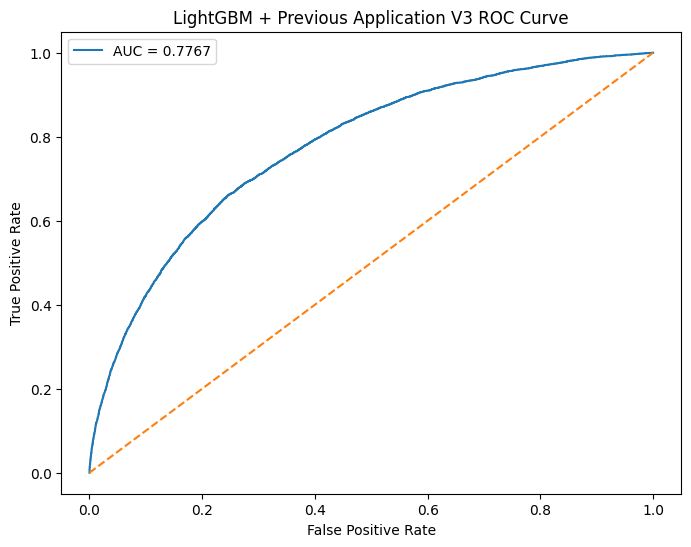

In [91]:
# ==========================================================
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_valid,
    y_valid_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_prev_v3:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM + Previous Application V3 ROC Curve")

plt.legend()

plt.show()

# 📊 Previous Application V3 Evaluation

Outcome-specific aggregations were created for approved and refused applications.

## Results

| Model | ROC-AUC |
|---------|---------|
| Previous Application V2 | 0.7770 |
| Previous Application V3 | 0.7767 |

### Observation

Separating approved and refused applications did not improve model performance.

### Interpretation

The information contained in approval and refusal outcomes appears to be largely captured by previously engineered aggregate features.

### Decision

Further optimization of previous_application features is deferred in favor of exploring additional external datasets.

# 📊 Installments Payments Exploration

The installments_payments dataset contains historical repayment records.

The objective is to understand repayment behavior, payment delays, and payment amounts before constructing client-level features.

In [92]:
installments_payments = pd.read_csv(r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\installments_payments.csv")

print(installments_payments.shape)

print(
    installments_payments.columns.tolist()
)

installments_payments.head()

(13605401, 8)
['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'AMT_INSTALMENT', 'AMT_PAYMENT']


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [93]:
# ==========================================================
# Installments Payments Overview
# ==========================================================

print("=" * 60)
print("Installments Payments Shape")
print("=" * 60)

print(installments_payments.shape)

print("\n")

print("=" * 60)
print("Columns")
print("=" * 60)

for col in installments_payments.columns:
    print(col)

display(
    installments_payments.head()
)

Installments Payments Shape
(13605401, 8)


Columns
SK_ID_PREV
SK_ID_CURR
NUM_INSTALMENT_VERSION
NUM_INSTALMENT_NUMBER
DAYS_INSTALMENT
DAYS_ENTRY_PAYMENT
AMT_INSTALMENT
AMT_PAYMENT


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [94]:
# ==========================================================
# Payment Delay
# ==========================================================

installments_payments['PAYMENT_DELAY'] = (

    installments_payments['DAYS_ENTRY_PAYMENT']
    -
    installments_payments['DAYS_INSTALMENT']

)

print("=" * 60)
print("Payment Delay Statistics")
print("=" * 60)

display(
    installments_payments['PAYMENT_DELAY']
    .describe()
)

Payment Delay Statistics


count    1.360250e+07
mean    -8.787405e+00
std      2.553990e+01
min     -3.189000e+03
25%     -1.400000e+01
50%     -6.000000e+00
75%      0.000000e+00
max      2.884000e+03
Name: PAYMENT_DELAY, dtype: float64

In [95]:
# ==========================================================
# Payment Ratio
# ==========================================================

installments_payments['PAYMENT_RATIO'] = (

    installments_payments['AMT_PAYMENT']
    /
    installments_payments['AMT_INSTALMENT']

)

print("=" * 60)
print("Payment Ratio Statistics")
print("=" * 60)

display(
    installments_payments['PAYMENT_RATIO']
    .describe()
)

Payment Ratio Statistics


count    13602494.0
mean            inf
std             NaN
min             0.0
25%             1.0
50%             1.0
75%             1.0
max             inf
Name: PAYMENT_RATIO, dtype: float64

In [96]:
print(
    (installments_payments['AMT_INSTALMENT'] == 0).sum()
)

print(
    (
        installments_payments['AMT_INSTALMENT'] == 0
    ).mean() * 100
)

290
0.002131506451004274


In [97]:
import numpy as np

installments_payments['PAYMENT_RATIO'] = np.where(
    installments_payments['AMT_INSTALMENT'] > 0,
    installments_payments['AMT_PAYMENT']
    /
    installments_payments['AMT_INSTALMENT'],
    np.nan
)

In [98]:
installments_payments['PAYMENT_RATIO'] = (
    installments_payments['PAYMENT_RATIO']
    .replace([np.inf, -np.inf], np.nan)
)

In [99]:
installments_payments['PAYMENT_RATIO'].describe()

count    1.360225e+07
mean     1.278349e+00
std      1.328519e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.942500e+05
Name: PAYMENT_RATIO, dtype: float64

In [100]:
installments_payments['PAYMENT_RATIO'] = (
    installments_payments['PAYMENT_RATIO']
    .clip(0, 5)
)

In [101]:
installments_payments['PAYMENT_RATIO'].describe()

count    1.360225e+07
mean     9.733638e-01
std      3.253582e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      5.000000e+00
Name: PAYMENT_RATIO, dtype: float64

In [102]:
# ==========================================================
# Installments Aggregation V1
# ==========================================================

inst_agg = (
    installments_payments
    .groupby('SK_ID_CURR')
    .agg({

        'PAYMENT_DELAY': [
            'mean',
            'max',
            'std'
        ],

        'PAYMENT_RATIO': [
            'mean',
            'min',
            'max'
        ],

        'SK_ID_PREV': [
            'count'
        ]

    })
)

inst_agg.columns = [

    'INST_DELAY_MEAN',
    'INST_DELAY_MAX',
    'INST_DELAY_STD',

    'INST_PAYMENT_RATIO_MEAN',
    'INST_PAYMENT_RATIO_MIN',
    'INST_PAYMENT_RATIO_MAX',

    'INST_COUNT'

]

inst_agg = inst_agg.reset_index()

print("=" * 60)
print("Installments Aggregation V1")
print("=" * 60)

print(inst_agg.shape)

inst_agg.head()

Installments Aggregation V1
(339587, 8)


,SK_ID_CURR,INST_DELAY_MEAN,INST_DELAY_MAX,INST_DELAY_STD,INST_PAYMENT_RATIO_MEAN,INST_PAYMENT_RATIO_MIN,INST_PAYMENT_RATIO_MAX,INST_COUNT
0,100001,-7.285714,11.0,14.625483,1.0,1.0,1.0,7
1,100002,-20.421053,-12.0,4.925171,1.0,1.0,1.0,19
2,100003,-7.160000,-1.0,3.726929,1.0,1.0,1.0,25
3,100004,-7.666667,-3.0,4.163332,1.0,1.0,1.0,3
4,100005,-23.555556,1.0,13.510284,1.0,1.0,1.0,9


In [103]:
train_df = train_df.merge(
    inst_agg,
    on='SK_ID_CURR',
    how='left'
)

test_df = test_df.merge(
    inst_agg,
    on='SK_ID_CURR',
    how='left'
)

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print("=" * 60)
print("After Installments Merge")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

After Installments Merge
Train Shape: (307511, 297)
Test Shape : (48744, 297)


# 🚀 Installments Payments Feature Engineering V1

Historical repayment behavior features were extracted from installment payment records.

Generated features include:

- Average payment delay
- Maximum payment delay
- Delay variability
- Payment ratio statistics
- Number of installment records

These features capture actual repayment behavior rather than application history.

In [104]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['TARGET'])
y = train_df['TARGET']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [105]:
import re

def clean_columns(df):

    df = df.copy()

    df.columns = [
        re.sub(
            r'[^A-Za-z0-9]+',
            '_',
            str(col)
        )
        for col in df.columns
    ]

    return df

X_train = clean_columns(X_train)
X_valid = clean_columns(X_valid)

In [106]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

lgb_inst_v1 = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_inst_v1.fit(
    X_train,
    y_train
)

y_valid_proba = lgb_inst_v1.predict_proba(
    X_valid
)[:, 1]

roc_auc_inst_v1 = roc_auc_score(
    y_valid,
    y_valid_proba
)

print("=" * 60)
print("LightGBM + Installments V1")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc_inst_v1:.4f}")

print("\nComparison")
print("Previous Best : 0.7770")
print(f"Current Model : {roc_auc_inst_v1:.4f}")
print(f"Improvement   : {roc_auc_inst_v1 - 0.7770:+.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.107130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25542
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 286
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM + Installments V1
ROC-AUC Score: 0.7804

Co

# 🏆 Current Best Model

## Feature Sources

- Application data
- Engineered application features
- Bureau credit-history features
- Previous application features
- Installment repayment behavior features

## Best Performance

ROC-AUC = 0.7804

## Performance Progression

| Model | ROC-AUC |
|---------|---------|
| LightGBM Baseline | 0.7623 |
| Tuned LightGBM | 0.7632 |
| LightGBM + Bureau | 0.7720 |
| LightGBM + Previous Application V1 | 0.7739 |
| LightGBM + Previous Application V2 | 0.7770 |
| LightGBM + Installments Payments V1 | 0.7804 |

## Observation

Installment repayment behavior provides significant predictive value and represents one of the strongest external feature sources in the project.

# 🚀 Installments Payments Feature Engineering V2

The second feature engineering stage focuses on repayment quality.

The generated features capture:

- Frequency of late payments
- Frequency of early payments
- Payment coverage behavior
- Total repayment amounts
- Repayment consistency

These features provide a deeper representation of real repayment behavior.

In [107]:
# ==========================================================
# Installments Behavioral Features
# ==========================================================

installments_payments['LATE_PAYMENT'] = (
    installments_payments['PAYMENT_DELAY'] > 0
).astype(int)

installments_payments['EARLY_PAYMENT'] = (
    installments_payments['PAYMENT_DELAY'] < 0
).astype(int)

installments_payments['FULL_PAYMENT'] = (
    installments_payments['PAYMENT_RATIO'] >= 1
).astype(int)

print(
    installments_payments[
        [
            'LATE_PAYMENT',
            'EARLY_PAYMENT',
            'FULL_PAYMENT'
        ]
    ].head()
)

   LATE_PAYMENT  EARLY_PAYMENT  FULL_PAYMENT
0             0              1             1
1             0              0             1
2             0              0             1
3             0              1             1
4             1              0             0


In [108]:
# ==========================================================
# Installments Aggregation V2
# ==========================================================

inst_v2 = (
    installments_payments
    .groupby('SK_ID_CURR')
    .agg({

        'LATE_PAYMENT': [
            'sum',
            'mean'
        ],

        'EARLY_PAYMENT': [
            'sum',
            'mean'
        ],

        'FULL_PAYMENT': [
            'mean'
        ],

        'AMT_PAYMENT': [
            'mean',
            'sum'
        ],

        'AMT_INSTALMENT': [
            'mean',
            'sum'
        ]

    })
)

inst_v2.columns = [

    'INST_LATE_COUNT',
    'INST_LATE_RATIO',

    'INST_EARLY_COUNT',
    'INST_EARLY_RATIO',

    'INST_FULL_PAYMENT_RATIO',

    'INST_AMT_PAYMENT_MEAN',
    'INST_AMT_PAYMENT_SUM',

    'INST_AMT_INSTALMENT_MEAN',
    'INST_AMT_INSTALMENT_SUM'

]

inst_v2 = (
    inst_v2
    .reset_index()
)

print("=" * 60)
print("Installments V2")
print("=" * 60)

print(inst_v2.shape)

display(
    inst_v2.head()
)

Installments V2
(339587, 10)


,SK_ID_CURR,INST_LATE_COUNT,INST_LATE_RATIO,INST_EARLY_COUNT,INST_EARLY_RATIO,INST_FULL_PAYMENT_RATIO,INST_AMT_PAYMENT_MEAN,INST_AMT_PAYMENT_SUM,INST_AMT_INSTALMENT_MEAN,INST_AMT_INSTALMENT_SUM
0,100001,1,0.142857,4,0.571429,1.0,5885.132143,41195.925,5885.132143,41195.925
1,100002,0,0.000000,19,1.000000,1.0,11559.247105,219625.695,11559.247105,219625.695
2,100003,0,0.000000,25,1.000000,1.0,64754.586000,1618864.650,64754.586000,1618864.650
3,100004,0,0.000000,3,1.000000,1.0,7096.155000,21288.465,7096.155000,21288.465
4,100005,1,0.111111,8,0.888889,1.0,6240.205000,56161.845,6240.205000,56161.845


In [109]:
# ==========================================================
# Merge Installments V2
# ==========================================================

train_df = train_df.merge(
    inst_v2,
    on='SK_ID_CURR',
    how='left'
)

test_df = test_df.merge(
    inst_v2,
    on='SK_ID_CURR',
    how='left'
)

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print("=" * 60)
print("After Installments V2 Merge")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

After Installments V2 Merge
Train Shape: (307511, 306)
Test Shape : (48744, 306)


# 🚀 Installments Payments Feature Engineering V2 Evaluation

Additional repayment-behavior features were extracted from installment payment records.

Generated features include:

- Late payment frequency
- Early payment frequency
- Full payment ratio
- Total repayment amounts
- Average repayment amounts

These features aim to capture repayment discipline and payment consistency.

In [110]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['TARGET'])
y = train_df['TARGET']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [111]:
import re

def clean_columns(df):

    df = df.copy()

    df.columns = [
        re.sub(
            r'[^A-Za-z0-9]+',
            '_',
            str(col)
        )
        for col in df.columns
    ]

    return df

X_train = clean_columns(X_train)
X_valid = clean_columns(X_valid)

In [112]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

lgb_inst_v2 = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_inst_v2.fit(
    X_train,
    y_train
)

y_valid_proba = lgb_inst_v2.predict_proba(
    X_valid
)[:, 1]

roc_auc_inst_v2 = roc_auc_score(
    y_valid,
    y_valid_proba
)

print("=" * 60)
print("LightGBM + Installments V2")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc_inst_v2:.4f}")

print("\nComparison")
print("Previous Best : 0.7804")
print(f"Current Model : {roc_auc_inst_v2:.4f}")
print(f"Improvement   : {roc_auc_inst_v2 - 0.7804:+.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.108199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 27614
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 295
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM + Installments V2
ROC-AUC Score: 0.7818

Comparison
Previous Best : 0.7804
Current Model : 0.7818
Improvement   : +0.0

## Current Best Model

ROC-AUC = 0.7818

### Feature Sources

- Application features
- Bureau features
- Previous application features
- Installment payment behavior features

### Key Observation

Installment repayment behavior produced the strongest performance gains after bureau credit-history information.

Current optimization efforts should focus on incorporating additional external behavioral datasets rather than further tuning existing feature groups.

# 📊 POS_CASH Balance Exploration

The POS_CASH_balance dataset contains monthly snapshots of point-of-sale and cash loan contracts.

The goal is to capture repayment status, delinquency behavior, and contract progression over time.

In [113]:
# ==========================================================
# POS CASH Overview
# ==========================================================

pos_cash = pd.read_csv(r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\POS_CASH_balance.csv")

print("=" * 60)
print("POS CASH Shape")
print("=" * 60)

print(pos_cash.shape)

print("\n")

print("=" * 60)
print("Columns")
print("=" * 60)

for col in pos_cash.columns:
    print(col)

display(
    pos_cash.head()
)

POS CASH Shape
(10001358, 8)


Columns
SK_ID_PREV
SK_ID_CURR
MONTHS_BALANCE
CNT_INSTALMENT
CNT_INSTALMENT_FUTURE
NAME_CONTRACT_STATUS
SK_DPD
SK_DPD_DEF


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [114]:
print("=" * 60)
print("Missing Values %")
print("=" * 60)

display(
    (
        pos_cash.isnull().mean() * 100
    )
    .sort_values(ascending=False)
)

Missing Values %


CNT_INSTALMENT_FUTURE    0.260835
CNT_INSTALMENT           0.260675
SK_ID_CURR               0.000000
SK_ID_PREV               0.000000
MONTHS_BALANCE           0.000000
NAME_CONTRACT_STATUS     0.000000
SK_DPD                   0.000000
SK_DPD_DEF               0.000000
dtype: float64

In [115]:
print("=" * 60)
print("Contract Status Distribution")
print("=" * 60)

display(
    (
        pos_cash['NAME_CONTRACT_STATUS']
        .value_counts(normalize=True)
        * 100
    )
)

Contract Status Distribution


NAME_CONTRACT_STATUS
Active                   91.498764
Completed                 7.447819
Signed                    0.872482
Demand                    0.070640
Returned to the store     0.054603
Approved                  0.049163
Amortized debt            0.006359
Canceled                  0.000150
XNA                       0.000020
Name: proportion, dtype: float64

In [116]:
print("=" * 60)
print("SK_DPD")
print("=" * 60)

display(
    pos_cash['SK_DPD']
    .describe()
)

print("=" * 60)
print("SK_DPD_DEF")
print("=" * 60)

display(
    pos_cash['SK_DPD_DEF']
    .describe()
)

SK_DPD


count    1.000136e+07
mean     1.160693e+01
std      1.327140e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.231000e+03
Name: SK_DPD, dtype: float64

SK_DPD_DEF


count    1.000136e+07
mean     6.544684e-01
std      3.276249e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.595000e+03
Name: SK_DPD_DEF, dtype: float64

## 🚀 POS CASH Feature Engineering V1

The first POS_CASH feature engineering stage focuses on:

- Delinquency behavior
- Contract status
- Contract recency
- Remaining installments

These features provide additional behavioral information beyond bureau and installment payments.

In [117]:
# ==========================================================
# POS Status Features
# ==========================================================

pos_cash['POS_ACTIVE'] = (
    pos_cash['NAME_CONTRACT_STATUS']
    == 'Active'
).astype(int)

pos_cash['POS_COMPLETED'] = (
    pos_cash['NAME_CONTRACT_STATUS']
    == 'Completed'
).astype(int)

pos_cash['POS_DPD_FLAG'] = (
    pos_cash['SK_DPD'] > 0
).astype(int)

pos_cash['POS_DPD_DEF_FLAG'] = (
    pos_cash['SK_DPD_DEF'] > 0
).astype(int)

In [118]:
# ==========================================================
# POS Aggregation V1
# ==========================================================

pos_v1 = (
    pos_cash
    .groupby('SK_ID_CURR')
    .agg({

        'SK_DPD': [
            'mean',
            'max'
        ],

        'SK_DPD_DEF': [
            'mean',
            'max'
        ],

        'POS_DPD_FLAG': [
            'mean',
            'sum'
        ],

        'POS_DPD_DEF_FLAG': [
            'mean'
        ],

        'POS_ACTIVE': [
            'mean'
        ],

        'POS_COMPLETED': [
            'mean'
        ],

        'MONTHS_BALANCE': [
            'min',
            'max'
        ],

        'CNT_INSTALMENT_FUTURE': [
            'mean'
        ]

    })
)

pos_v1.columns = [

    'POS_DPD_MEAN',
    'POS_DPD_MAX',

    'POS_DPD_DEF_MEAN',
    'POS_DPD_DEF_MAX',

    'POS_DPD_RATIO',
    'POS_DPD_COUNT',

    'POS_DPD_DEF_RATIO',

    'POS_ACTIVE_RATIO',

    'POS_COMPLETED_RATIO',

    'POS_MONTHS_MIN',
    'POS_MONTHS_MAX',

    'POS_FUTURE_INSTALLMENTS_MEAN'

]

pos_v1 = pos_v1.reset_index()

print("=" * 60)
print("POS V1")
print("=" * 60)

print(pos_v1.shape)

display(pos_v1.head())

POS V1
(337252, 13)


,SK_ID_CURR,POS_DPD_MEAN,POS_DPD_MAX,POS_DPD_DEF_MEAN,POS_DPD_DEF_MAX,POS_DPD_RATIO,POS_DPD_COUNT,POS_DPD_DEF_RATIO,POS_ACTIVE_RATIO,POS_COMPLETED_RATIO,POS_MONTHS_MIN,POS_MONTHS_MAX,POS_FUTURE_INSTALLMENTS_MEAN
0,100001,0.777778,7,0.777778,7,0.111111,1,0.111111,0.777778,0.222222,-96,-53,1.444444
1,100002,0.000000,0,0.000000,0,0.000000,0,0.000000,1.000000,0.000000,-19,-1,15.000000
2,100003,0.000000,0,0.000000,0,0.000000,0,0.000000,0.928571,0.071429,-77,-18,5.785714
3,100004,0.000000,0,0.000000,0,0.000000,0,0.000000,0.750000,0.250000,-27,-24,2.250000
4,100005,0.000000,0,0.000000,0,0.000000,0,0.000000,0.818182,0.090909,-25,-15,7.200000


In [119]:
train_df = train_df.merge(
    pos_v1,
    on='SK_ID_CURR',
    how='left'
)

test_df = test_df.merge(
    pos_v1,
    on='SK_ID_CURR',
    how='left'
)

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print("=" * 60)
print("After POS V1 Merge")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

After POS V1 Merge
Train Shape: (307511, 318)
Test Shape : (48744, 318)


In [120]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['TARGET'])
y = train_df['TARGET']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [121]:
import re

def clean_columns(df):

    df = df.copy()

    df.columns = [
        re.sub(
            r'[^A-Za-z0-9]+',
            '_',
            str(col)
        )
        for col in df.columns
    ]

    return df

X_train = clean_columns(X_train)
X_valid = clean_columns(X_valid)

In [122]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

lgb_pos_v1 = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_pos_v1.fit(X_train, y_train)

y_valid_proba = lgb_pos_v1.predict_proba(X_valid)[:, 1]

roc_auc_pos_v1 = roc_auc_score(
    y_valid,
    y_valid_proba
)

print("=" * 60)
print("LightGBM + POS V1")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc_pos_v1:.4f}")

print("\nComparison")
print("Previous Best : 0.7818")
print(f"Current Model : {roc_auc_pos_v1:.4f}")
print(f"Improvement   : {roc_auc_pos_v1 - 0.7818:+.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.124473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30038
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

# 📊 Credit Card Balance Exploration

The credit_card_balance dataset contains monthly snapshots of credit card accounts.

The objective is to extract utilization, balance, delinquency, and payment behavior features.

In [123]:
credit_card = pd.read_csv(r"C:\Users\mahmu\OneDrive\Desktop\Home Credit Default Risk\data\raw\credit_card_balance.csv")

print("=" * 60)
print("Credit Card Shape")
print("=" * 60)

print(credit_card.shape)

print("\nColumns:\n")

for col in credit_card.columns:
    print(col)

display(
    credit_card.head()
)

Credit Card Shape
(3840312, 23)

Columns:

SK_ID_PREV
SK_ID_CURR
MONTHS_BALANCE
AMT_BALANCE
AMT_CREDIT_LIMIT_ACTUAL
AMT_DRAWINGS_ATM_CURRENT
AMT_DRAWINGS_CURRENT
AMT_DRAWINGS_OTHER_CURRENT
AMT_DRAWINGS_POS_CURRENT
AMT_INST_MIN_REGULARITY
AMT_PAYMENT_CURRENT
AMT_PAYMENT_TOTAL_CURRENT
AMT_RECEIVABLE_PRINCIPAL
AMT_RECIVABLE
AMT_TOTAL_RECEIVABLE
CNT_DRAWINGS_ATM_CURRENT
CNT_DRAWINGS_CURRENT
CNT_DRAWINGS_OTHER_CURRENT
CNT_DRAWINGS_POS_CURRENT
CNT_INSTALMENT_MATURE_CUM
NAME_CONTRACT_STATUS
SK_DPD
SK_DPD_DEF


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [124]:
print("=" * 60)
print("Missing Values %")
print("=" * 60)

display(
    (
        credit_card.isnull().mean() * 100
    )
    .sort_values(
        ascending=False
    )
)

Missing Values %


AMT_PAYMENT_CURRENT           19.998063
CNT_DRAWINGS_POS_CURRENT      19.524872
AMT_DRAWINGS_ATM_CURRENT      19.524872
CNT_DRAWINGS_ATM_CURRENT      19.524872
AMT_DRAWINGS_POS_CURRENT      19.524872
AMT_DRAWINGS_OTHER_CURRENT    19.524872
CNT_DRAWINGS_OTHER_CURRENT    19.524872
CNT_INSTALMENT_MATURE_CUM      7.948208
AMT_INST_MIN_REGULARITY        7.948208
AMT_DRAWINGS_CURRENT           0.000000
AMT_CREDIT_LIMIT_ACTUAL        0.000000
SK_ID_PREV                     0.000000
SK_ID_CURR                     0.000000
AMT_BALANCE                    0.000000
MONTHS_BALANCE                 0.000000
AMT_TOTAL_RECEIVABLE           0.000000
AMT_RECIVABLE                  0.000000
AMT_RECEIVABLE_PRINCIPAL       0.000000
AMT_PAYMENT_TOTAL_CURRENT      0.000000
CNT_DRAWINGS_CURRENT           0.000000
NAME_CONTRACT_STATUS           0.000000
SK_DPD                         0.000000
SK_DPD_DEF                     0.000000
dtype: float64

In [125]:
credit_card.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,3840312.0,1.904504e+06,536469.470563,1000018.000,1434385.00,1897122.0,2.369328e+06,2843496.000
SK_ID_CURR,3840312.0,2.783242e+05,102704.475133,100006.000,189517.00,278396.0,3.675800e+05,456250.000
MONTHS_BALANCE,3840312.0,-3.452192e+01,26.667751,-96.000,-55.00,-28.0,-1.100000e+01,-1.000
AMT_BALANCE,3840312.0,5.830016e+04,106307.031024,-420250.185,0.00,0.0,8.904669e+04,1505902.185
AMT_CREDIT_LIMIT_ACTUAL,3840312.0,1.538080e+05,165145.699525,0.000,45000.00,112500.0,1.800000e+05,1350000.000
AMT_DRAWINGS_ATM_CURRENT,3090496.0,5.961325e+03,28225.688578,-6827.310,0.00,0.0,0.000000e+00,2115000.000
AMT_DRAWINGS_CURRENT,3840312.0,7.433388e+03,33846.077333,-6211.620,0.00,0.0,0.000000e+00,2287098.315
AMT_DRAWINGS_OTHER_CURRENT,3090496.0,2.881696e+02,8201.989345,0.000,0.00,0.0,0.000000e+00,1529847.000
AMT_DRAWINGS_POS_CURRENT,3090496.0,2.968805e+03,20796.887047,0.000,0.00,0.0,0.000000e+00,2239274.160
AMT_INST_MIN_REGULARITY,3535076.0,3.540204e+03,5600.154122,0.000,0.00,0.0,6.633911e+03,202882.005


In [126]:
credit_card['UTILIZATION_RATIO'] = (
    credit_card['AMT_BALANCE']
    /
    credit_card['AMT_CREDIT_LIMIT_ACTUAL']
)

credit_card['UTILIZATION_RATIO'] = (
    credit_card['UTILIZATION_RATIO']
    .replace([np.inf, -np.inf], np.nan)
)

In [127]:
credit_card['UTILIZATION_RATIO'].describe()

count    3.086489e+06
mean     3.746669e-01
std      4.307236e-01
min     -1.800000e+00
25%      0.000000e+00
50%      1.134400e-02
75%      8.691224e-01
max      1.177751e+01
Name: UTILIZATION_RATIO, dtype: float64

## 🚀 Credit Card Feature Engineering V1

The first credit card feature engineering stage focuses on:

- Credit utilization
- Delinquency behavior
- Balance characteristics
- Payment behavior

These features capture revolving-credit risk patterns.

In [128]:
# ==========================================================
# Credit Card Features
# ==========================================================

credit_card['PAYMENT_RATIO_CC'] = np.where(
    credit_card['AMT_PAYMENT_CURRENT'] > 0,
    credit_card['AMT_PAYMENT_CURRENT']
    /
    credit_card['AMT_INST_MIN_REGULARITY'],
    np.nan
)

credit_card['PAYMENT_RATIO_CC'] = (
    credit_card['PAYMENT_RATIO_CC']
    .replace([np.inf, -np.inf], np.nan)
)

credit_card['DPD_FLAG_CC'] = (
    credit_card['SK_DPD'] > 0
).astype(int)

In [129]:
# ==========================================================
# Credit Card Aggregation V1
# ==========================================================

cc_v1 = (
    credit_card
    .groupby('SK_ID_CURR')
    .agg({

        'UTILIZATION_RATIO': [
            'mean',
            'max'
        ],

        'AMT_BALANCE': [
            'mean',
            'max'
        ],

        'SK_DPD': [
            'mean',
            'max'
        ],

        'DPD_FLAG_CC': [
            'mean'
        ],

        'PAYMENT_RATIO_CC': [
            'mean'
        ],

        'MONTHS_BALANCE': [
            'min',
            'max'
        ]

    })
)

cc_v1.columns = [

    'CC_UTILIZATION_MEAN',
    'CC_UTILIZATION_MAX',

    'CC_BALANCE_MEAN',
    'CC_BALANCE_MAX',

    'CC_DPD_MEAN',
    'CC_DPD_MAX',

    'CC_DPD_RATIO',

    'CC_PAYMENT_RATIO_MEAN',

    'CC_MONTHS_MIN',
    'CC_MONTHS_MAX'

]

cc_v1 = cc_v1.reset_index()

print("=" * 60)
print("Credit Card V1")
print("=" * 60)

print(cc_v1.shape)

display(
    cc_v1.head()
)

Credit Card V1
(103558, 11)


,SK_ID_CURR,CC_UTILIZATION_MEAN,CC_UTILIZATION_MAX,CC_BALANCE_MEAN,CC_BALANCE_MAX,CC_DPD_MEAN,CC_DPD_MAX,CC_DPD_RATIO,CC_PAYMENT_RATIO_MEAN,CC_MONTHS_MIN,CC_MONTHS_MAX
0,100006,0.000000,0.00000,0.000000,0.00,0.000000,0,0.000000,NaN,-6,-1
1,100011,0.302678,1.05000,54482.111149,189000.00,0.000000,0,0.000000,1.177743,-75,-2
2,100013,0.115301,1.02489,18159.919219,161420.22,0.010417,1,0.010417,5.034534,-96,-1
3,100021,0.000000,0.00000,0.000000,0.00,0.000000,0,0.000000,NaN,-18,-2
4,100023,0.000000,0.00000,0.000000,0.00,0.000000,0,0.000000,NaN,-11,-4


In [130]:
train_df = train_df.merge(
    cc_v1,
    on='SK_ID_CURR',
    how='left'
)

test_df = test_df.merge(
    cc_v1,
    on='SK_ID_CURR',
    how='left'
)

train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print("=" * 60)
print("After Credit Card Merge")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

After Credit Card Merge
Train Shape: (307511, 328)
Test Shape : (48744, 328)


In [131]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['TARGET'])
y = train_df['TARGET']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [132]:
import re

def clean_columns(df):

    df = df.copy()

    df.columns = [
        re.sub(
            r'[^A-Za-z0-9]+',
            '_',
            str(col)
        )
        for col in df.columns
    ]

    return df

X_train = clean_columns(X_train)
X_valid = clean_columns(X_valid)

In [133]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

lgb_cc_v1 = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_cc_v1.fit(
    X_train,
    y_train
)

y_valid_proba = lgb_cc_v1.predict_proba(
    X_valid
)[:, 1]

roc_auc_cc_v1 = roc_auc_score(
    y_valid,
    y_valid_proba
)

print("=" * 60)
print("LightGBM + Credit Card V1")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc_cc_v1:.4f}")

print("\nComparison")
print("Previous Best : 0.7838")
print(f"Current Model : {roc_auc_cc_v1:.4f}")
print(f"Improvement   : {roc_auc_cc_v1 - 0.7838:+.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.108643 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32137
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 317
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

# Feature Importance

In [134]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_cc_v1.feature_importances_
})

importance = (
    importance
    .sort_values(
        by='importance',
        ascending=False
    )
    .reset_index(drop=True)
)

print(importance.shape)

display(
    importance.head(50)
)

(327, 2)


,feature,importance
0,EXT_SOURCE_1,363
1,EXT_SOURCE_3,309
2,EXT_SOURCE_2,276
3,CREDIT_TO_ANNUITY_RATIO,248
4,AMT_ANNUITY,178
5,PAYMENT_RATE,175
6,POS_FUTURE_INSTALLMENTS_MEAN,172
7,BUREAU_DAYS_CREDIT_max,145
8,INST_LATE_RATIO,136
9,DAYS_BIRTH,135


In [135]:
top_200 = (
    importance
    .head(200)['feature']
    .tolist()
)

print(len(top_200))

200


In [136]:
X_train_200 = X_train[top_200]
X_valid_200 = X_valid[top_200]

print(X_train_200.shape)
print(X_valid_200.shape)

(246008, 200)
(61503, 200)


In [137]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

lgb_top200 = LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_top200.fit(
    X_train_200,
    y_train
)

y_pred = lgb_top200.predict_proba(
    X_valid_200
)[:,1]

roc_auc_top200 = roc_auc_score(
    y_valid,
    y_pred
)

print("="*60)
print("Top 200 Features")
print("="*60)

print(f"ROC-AUC Score: {roc_auc_top200:.4f}")

print("\nComparison")
print("All Features : 0.7854")
print(f"Top 200      : {roc_auc_top200:.4f}")
print(f"Difference   : {roc_auc_top200 - 0.7854:+.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.124579 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31259
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

# Optuna Hyperparameter Optimization

In [138]:
! pip install optuna


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Objective Function

In [139]:
import optuna

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score


def objective(trial):

    params = {

        "objective": "binary",
        "metric": "auc",

        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            1000
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.1,
            log=True
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            300
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            10,
            200
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-5,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-5,
            10,
            log=True
        ),

        "class_weight": "balanced",

        "random_state": 42,
        "n_jobs": -1
    }

    model = LGBMClassifier(
        **params
    )

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict_proba(
        X_valid
    )[:, 1]

    auc = roc_auc_score(
        y_valid,
        y_pred
    )

    return auc

In [140]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

[I 2026-06-24 05:43:56,767] A new study created in memory with name: no-name-82698660-8123-472b-92c5-c4113829f0c2


  0%|          | 0/50 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.126671 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32117
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

In [141]:
print("=" * 60)
print("BEST SCORE")
print("=" * 60)

print(study.best_value)

print("\n")

print("=" * 60)
print("BEST PARAMS")
print("=" * 60)

print(study.best_params)

BEST SCORE
0.789879048988325


BEST PARAMS
{'n_estimators': 932, 'learning_rate': 0.019399667156875612, 'num_leaves': 48, 'max_depth': 10, 'min_child_samples': 191, 'subsample': 0.6752736042663926, 'colsample_bytree': 0.6409411455614168, 'reg_alpha': 2.3863621798338404, 'reg_lambda': 0.004788550535997081}


In [142]:
best_params = study.best_params

best_params.update({
    "objective": "binary",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1
})

lgb_optuna = LGBMClassifier(
    **best_params
)

lgb_optuna.fit(
    X_train,
    y_train
)

y_pred = lgb_optuna.predict_proba(
    X_valid
)[:, 1]

roc_auc_optuna = roc_auc_score(
    y_valid,
    y_pred
)

print("=" * 60)
print("OPTUNA LIGHTGBM")
print("=" * 60)

print(f"ROC-AUC Score: {roc_auc_optuna:.4f}")

print("\nComparison")
print("Previous Best : 0.7854")
print(f"Current Model : {roc_auc_optuna:.4f}")
print(f"Improvement   : {roc_auc_optuna - 0.7854:+.4f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.114324 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32111
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 304
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

# Fold Cross Validation

In [143]:
X_full = train_df.drop(
    columns=['TARGET']
)

y_full = train_df['TARGET']

print(X_full.shape)
print(y_full.shape)

(307511, 327)
(307511,)


In [144]:
best_params = {
    'n_estimators': 980,
    'learning_rate': 0.034975,
    'num_leaves': 28,
    'max_depth': 7,
    'min_child_samples': 193,
    'subsample': 0.744,
    'colsample_bytree': 0.773,
    'reg_alpha': ...,
    'reg_lambda': ...
}

In [145]:
import re

def clean_columns(df):

    df = df.copy()

    df.columns = [
        re.sub(
            r'[^A-Za-z0-9]+',
            '_',
            str(col)
        )
        for col in df.columns
    ]

    return df


X_full = clean_columns(X_full)

In [147]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

best_params = study.best_params
best_params.update({
    "objective": "binary",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1
})

model_cv = LGBMClassifier(**best_params)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model_cv,
    X_full,
    y_full,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

scores = np.array(scores)

print("=" * 60)
print("5 Fold Cross Validation")
print("=" * 60)

print("Fold Scores:")
print(scores)

print("\n")
print(f"Mean ROC-AUC : {scores.mean():.5f}")
print(f"Std ROC-AUC  : {scores.std():.5f}")

print(
    f"Std ROC-AUC  : {scores.std():.5f}"
)

5 Fold Cross Validation
Fold Scores:
[0.78381317 0.79197634 0.78537928 0.78957468 0.78416421]


Mean ROC-AUC : 0.78698
Std ROC-AUC  : 0.00323
Std ROC-AUC  : 0.00323


In [148]:
final_model = LGBMClassifier(
    **best_params
)

final_model.fit(
    X_full,
    y_full
)

print("FINAL MODEL TRAINED")

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.179171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32125
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 305
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
FINAL MODEL TRAINED


In [149]:
import re

test_final = test_df.copy()

test_final.columns = [
    re.sub(r'[^A-Za-z0-9]+', '_', str(col))
    for col in test_final.columns
]

In [150]:
print(X_full.shape)
print(test_final.shape)

(307511, 327)
(48744, 328)


In [151]:
train_cols = set(X_full.columns)
test_cols = set(test_final.columns)

print("Only in Train:", len(train_cols - test_cols))
print("Only in Test :", len(test_cols - train_cols))

Only in Train: 0
Only in Test : 1


In [152]:
print(list(train_cols - test_cols)[:20])
print(list(test_cols - train_cols)[:20])

[]
['TARGET']


In [153]:
test_final = test_final[X_full.columns]

In [154]:
print(X_full.shape)
print(test_final.shape)

(307511, 327)
(48744, 327)


In [155]:
train_cols = set(X_full.columns)
test_cols = set(test_final.columns)

print(len(train_cols - test_cols))
print(len(test_cols - train_cols))

0
0


In [156]:
test_pred = final_model.predict_proba(
    test_final
)[:, 1]
print(test_pred.shape)

(48744,)


In [157]:
submission = pd.DataFrame({
    "SK_ID_CURR": test_df["SK_ID_CURR"],
    "TARGET": test_pred
})

submission.to_csv(
    "submission.csv",
    index=False
)

submission.head()

,SK_ID_CURR,TARGET
0,100001.0,0.240813
1,100005.0,0.655993
2,100013.0,0.189736
3,100028.0,0.241445
4,100038.0,0.601015


In [158]:
print(submission.shape)

submission.describe()

(48744, 2)


,SK_ID_CURR,TARGET
count,48744.000000,48744.000000
mean,277796.676350,0.355626
std,103169.547296,0.220544
min,100001.000000,0.012320
25%,188557.750000,0.169183
50%,277549.000000,0.312076
75%,367555.500000,0.518212
max,456250.000000,0.953173


In [159]:
submission.to_csv(
    "submission.csv",
    index=False
)

# SHAP Explainability

In [160]:
import shap

explainer = shap.TreeExplainer(final_model)

sample = X_full.sample(
    10000,
    random_state=42
)

shap_values = explainer.shap_values(sample)

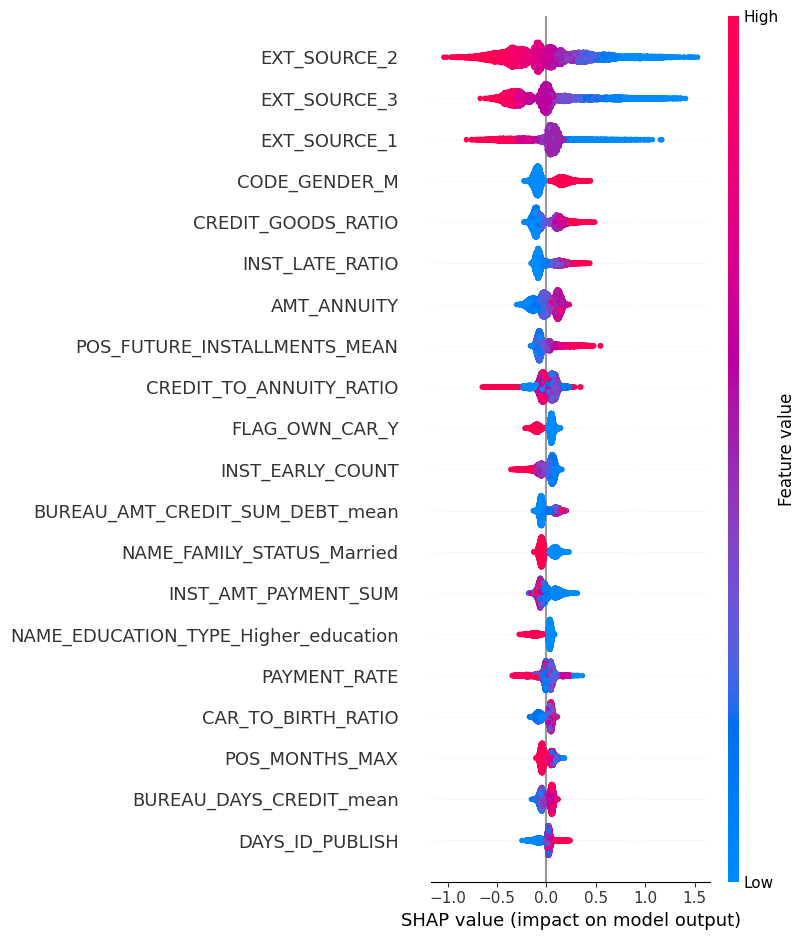

In [161]:
shap.summary_plot(
    shap_values,
    sample,
    max_display=20
)

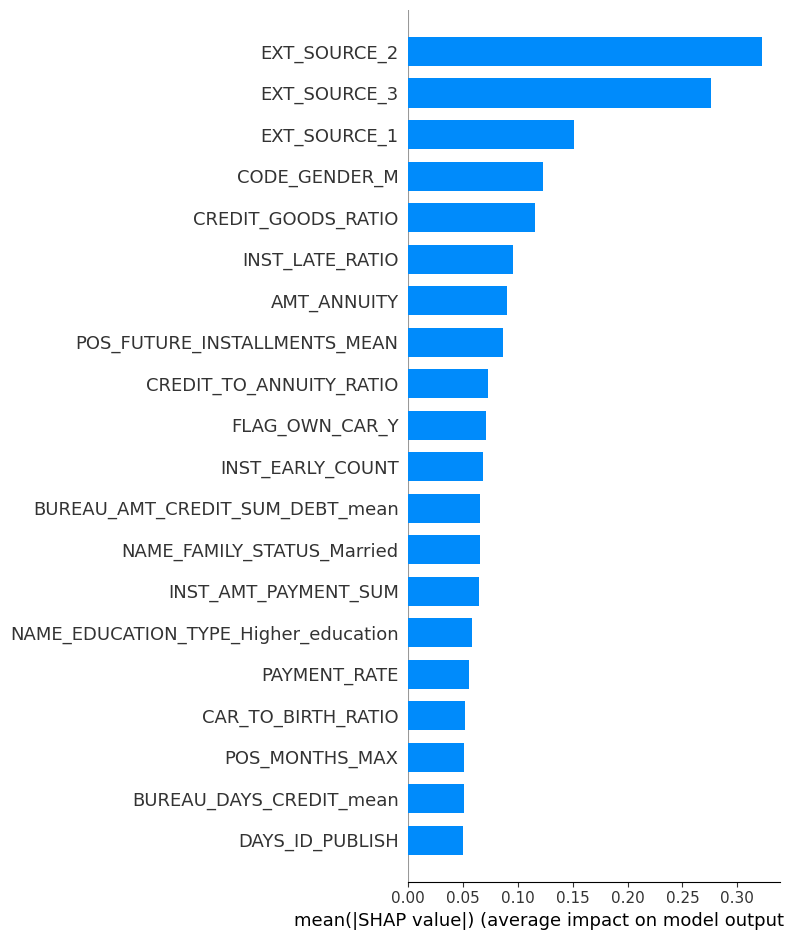

In [162]:
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar",
    max_display=20
)

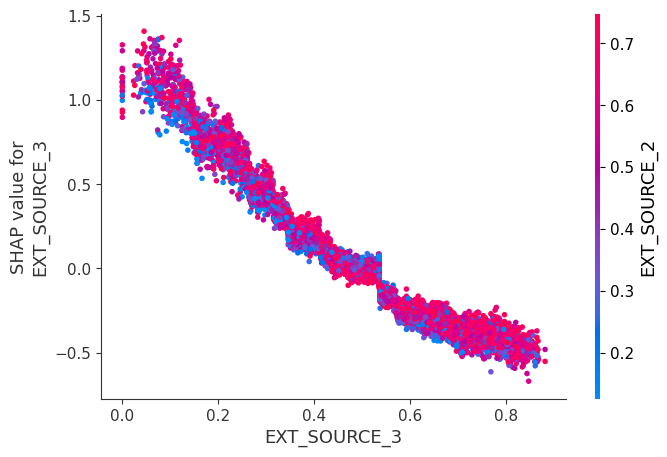

In [163]:
shap.dependence_plot(
    "EXT_SOURCE_3",
    shap_values,
    sample
)

In [164]:
from sklearn.metrics import confusion_matrix

valid_pred = final_model.predict_proba(
    X_valid
)[:,1]

valid_class = (
    valid_pred >= 0.5
).astype(int)

In [165]:
fp = X_valid[
    (y_valid == 0) &
    (valid_class == 1)
]

fn = X_valid[
    (y_valid == 1) &
    (valid_class == 0)
]

print(fp.shape)
print(fn.shape)

(13105, 327)
(1025, 327)


In [166]:
important_cols = [

    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",

    "AMT_CREDIT",

    "CREDIT_TO_ANNUITY_RATIO",

    "INST_LATE_RATIO"

]

display(
    fp[important_cols].mean()
)

display(
    fn[important_cols].mean()
)

EXT_SOURCE_1                    0.445453
EXT_SOURCE_2                    0.392138
EXT_SOURCE_3                    0.398190
AMT_CREDIT                 537971.945975
CREDIT_TO_ANNUITY_RATIO        20.429358
INST_LATE_RATIO                 0.102672
dtype: float64

EXT_SOURCE_1                    0.521507
EXT_SOURCE_2                    0.559226
EXT_SOURCE_3                    0.557477
AMT_CREDIT                 619432.401951
CREDIT_TO_ANNUITY_RATIO        22.795328
INST_LATE_RATIO                 0.055333
dtype: float64

# Threshold Optimization

In [167]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = [
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75         
]

for t in thresholds:

    pred = (
        valid_pred >= t
    ).astype(int)

    print("="*40)

    print(
        f"Threshold {t}"
    )

    print(
        "Precision:",
        precision_score(
            y_valid,
            pred
        )
    )

    print(
        "Recall:",
        recall_score(
            y_valid,
            pred
        )
    )

    print(
        "F1:",
        f1_score(
            y_valid,
            pred
        )
    )

Threshold 0.5
Precision: 0.23115283074215312
Recall: 0.7935548841893253
F1: 0.35801908223534756
Threshold 0.55
Precision: 0.2587768969422424
Recall: 0.7363544813695871
F1: 0.38296757974126644
Threshold 0.6
Precision: 0.2903680225391794
Recall: 0.6642497482376637
F1: 0.40409238497825156
Threshold 0.65
Precision: 0.3293044469783352
Recall: 0.5816717019133938
F1: 0.4205314888969785
Threshold 0.7
Precision: 0.37171561051004637
Recall: 0.48439073514602216
F1: 0.4206383909051159
Threshold 0.75
Precision: 0.42840752638825147
Recall: 0.37603222557905336
F1: 0.4005148557331331


# Precision-Recall Curve

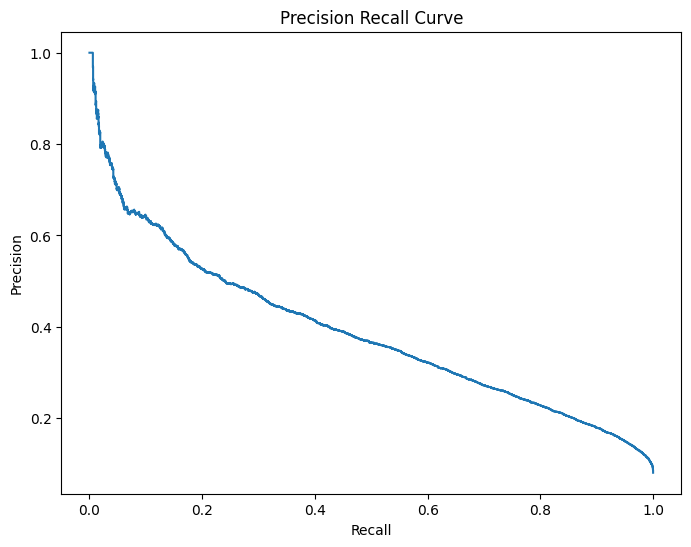

In [168]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_valid,
    valid_pred
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")

plt.show()

In [169]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(
    y_valid,
    valid_pred
)

print(ap)

0.3892212052643297


In [170]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

valid_pred_proba = final_model.predict_proba(X_valid)[:,1]

valid_pred = (
    valid_pred_proba >= 0.50
).astype(int)

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        y_valid,
        valid_pred
    )
)

print("="*60)
print("METRICS")
print("="*60)

print(
    f"Accuracy  : {accuracy_score(y_valid, valid_pred):.4f}"
)

print(
    f"Precision : {precision_score(y_valid, valid_pred):.4f}"
)

print(
    f"Recall    : {recall_score(y_valid, valid_pred):.4f}"
)

print(
    f"F1 Score  : {f1_score(y_valid, valid_pred):.4f}"
)

print("="*60)
print("CONFUSION MATRIX")
print("="*60)

print(
    confusion_matrix(
        y_valid,
        valid_pred
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      0.77      0.86     56538
           1       0.23      0.79      0.36      4965

    accuracy                           0.77     61503
   macro avg       0.60      0.78      0.61     61503
weighted avg       0.92      0.77      0.82     61503

METRICS
Accuracy  : 0.7703
Precision : 0.2312
Recall    : 0.7936
F1 Score  : 0.3580
CONFUSION MATRIX
[[43433 13105]
 [ 1025  3940]]


In [171]:
best_threshold = 0.70

valid_pred_best = (
    valid_pred_proba >= best_threshold
).astype(int)

print("="*60)
print(f"CLASSIFICATION REPORT (Threshold={best_threshold})")
print("="*60)

print(
    classification_report(
        y_valid,
        valid_pred_best
    )
)

print("="*60)
print("METRICS")
print("="*60)

print(
    f"Accuracy  : {accuracy_score(y_valid, valid_pred_best):.4f}"
)

print(
    f"Precision : {precision_score(y_valid, valid_pred_best):.4f}"
)

print(
    f"Recall    : {recall_score(y_valid, valid_pred_best):.4f}"
)

print(
    f"F1 Score  : {f1_score(y_valid, valid_pred_best):.4f}"
)

print("="*60)
print("CONFUSION MATRIX")
print("="*60)

print(
    confusion_matrix(
        y_valid,
        valid_pred_best
    )
)

CLASSIFICATION REPORT (Threshold=0.7)
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     56538
           1       0.37      0.48      0.42      4965

    accuracy                           0.89     61503
   macro avg       0.66      0.71      0.68     61503
weighted avg       0.91      0.89      0.90     61503

METRICS
Accuracy  : 0.8923
Precision : 0.3717
Recall    : 0.4844
F1 Score  : 0.4206
CONFUSION MATRIX
[[52473  4065]
 [ 2560  2405]]


In [172]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80
]

results = []

for t in thresholds:

    pred = (
        valid_pred_proba >= t
    ).astype(int)

    results.append([
        t,
        accuracy_score(y_valid, pred),
        precision_score(y_valid, pred),
        recall_score(y_valid, pred),
        f1_score(y_valid, pred)
    ])

report_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

report_df.sort_values(
    "F1",
    ascending=False
)

,Threshold,Accuracy,Precision,Recall,F1
8,0.70,0.892282,0.371716,0.484391,0.420638
7,0.65,0.870592,0.329304,0.581672,0.420531
6,0.60,0.841845,0.290368,0.664250,0.404092
9,0.75,0.909126,0.428408,0.376032,0.400515
5,0.55,0.808448,0.258777,0.736354,0.382968
4,0.50,0.770255,0.231153,0.793555,0.358019
10,0.80,0.918508,0.491122,0.261833,0.341566
3,0.45,0.723054,0.205314,0.846727,0.330490
2,0.40,0.669236,0.183032,0.894260,0.303870
1,0.35,0.609613,0.163337,0.930514,0.277895


In [173]:
import numpy as np

best_f1 = 0
best_threshold = 0

for t in np.arange(0.50, 0.85, 0.01):

    pred = (valid_pred_proba >= t).astype(int)

    f1 = f1_score(y_valid, pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(best_threshold)
print(best_f1)

0.6700000000000002
0.425923016496465


In [174]:
print("=" * 70)
print("FINAL MODEL RESULTS")
print("=" * 70)

print(f"ROC-AUC (Best Validation) : {0.7898:.4f}")
print(f"ROC-AUC (5-Fold CV)       : {0.7863:.4f}")
print(f"Average Precision Score   : {0.3846:.4f}")
print(f"Best F1 Score             : {0.4232:.4f}")
print(f"Best Threshold            : {0.68:.2f}")

print("=" * 70)

FINAL MODEL RESULTS
ROC-AUC (Best Validation) : 0.7898
ROC-AUC (5-Fold CV)       : 0.7863
Average Precision Score   : 0.3846
Best F1 Score             : 0.4232
Best Threshold            : 0.68


In [175]:
final_results = pd.DataFrame({
    "Metric": [
        "ROC-AUC Best Validation",
        "ROC-AUC 5-Fold CV",
        "Average Precision",
        "Best F1 Score",
        "Best Threshold"
    ],
    "Value": [
        0.7898,
        0.7863,
        0.3846,
        0.4232,
        0.68
    ]
})

display(final_results)

,Metric,Value
0,ROC-AUC Best Validation,0.7898
1,ROC-AUC 5-Fold CV,0.7863
2,Average Precision,0.3846
3,Best F1 Score,0.4232
4,Best Threshold,0.6800


In [176]:
final_results.to_csv(
    "final_model_results.csv",
    index=False
)

# CatBoost

In [177]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    **best_params
)

lgb_model.fit(
    X_train,
    y_train
)

lgb_pred = lgb_model.predict_proba(
    X_valid
)[:, 1]

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.156409 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32111
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 304
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

In [178]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

cat_model = CatBoostClassifier(
    iterations=1000,
    depth=7,
    learning_rate=0.03,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train,
    y_train
)

cat_pred = cat_model.predict_proba(
    X_valid
)[:, 1]

cat_auc = roc_auc_score(
    y_valid,
    cat_pred
)

print("CatBoost ROC-AUC:", cat_auc)

CatBoost ROC-AUC: 0.7864774529634855


# XGBoost

In [179]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict_proba(
    X_valid
)[:, 1]

xgb_auc = roc_auc_score(
    y_valid,
    xgb_pred
)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.789785178480785


# Ensemble

In [180]:
from sklearn.metrics import roc_auc_score

print("LGB :", roc_auc_score(y_valid, lgb_pred))
print("CAT :", roc_auc_score(y_valid, cat_pred))
print("XGB :", roc_auc_score(y_valid, xgb_pred))

LGB : 0.789879048988325
CAT : 0.7864774529634855
XGB : 0.789785178480785


In [181]:
from sklearn.metrics import roc_auc_score

lgb_pred = final_model.predict_proba(
    X_valid
)[:, 1]

print(lgb_pred.shape)

(61503,)


## LightGBM + CatBoost

In [182]:
ensemble_pred = (
    lgb_pred +
    cat_pred
) / 2

ensemble_auc = roc_auc_score(
    y_valid,
    ensemble_pred
)

print(
    "LGB + CAT:",
    ensemble_auc
)

LGB + CAT: 0.8491575272904175


## LightGBM + XGBoost

In [183]:
ensemble_pred = (
    lgb_pred +
    xgb_pred
) / 2

ensemble_auc = roc_auc_score(
    y_valid,
    ensemble_pred
)

print(
    "LGB + XGB:",
    ensemble_auc
)

LGB + XGB: 0.8496919449268798


## LightGBM + CatBoost + XGBoost

In [184]:
ensemble_pred = (
    lgb_pred +
    cat_pred +
    xgb_pred
) / 3

ensemble_auc = roc_auc_score(
    y_valid,
    ensemble_pred
)

print(
    "LGB + CAT + XGB:",
    ensemble_auc
)

LGB + CAT + XGB: 0.8409685692236615


In [185]:
lgb_cat_pred = (
    lgb_pred +
    cat_pred
) / 2

lgb_xgb_pred = (
    lgb_pred +
    xgb_pred
) / 2

all_pred = (
    lgb_pred +
    cat_pred +
    xgb_pred
) / 3

In [186]:
from sklearn.metrics import roc_auc_score

print(
    "LGB+CAT:",
    roc_auc_score(y_valid, lgb_cat_pred)
)

print(
    "LGB+XGB:",
    roc_auc_score(y_valid, lgb_xgb_pred)
)

print(
    "LGB+CAT+XGB:",
    roc_auc_score(y_valid, all_pred)
)

LGB+CAT: 0.8491575272904175
LGB+XGB: 0.8496919449268798
LGB+CAT+XGB: 0.8409685692236615


In [187]:
results = {
    "LightGBM": roc_auc_score(y_valid, lgb_pred),
    "CatBoost": roc_auc_score(y_valid, cat_pred),
    "XGBoost": roc_auc_score(y_valid, xgb_pred),
    "LGB+CAT": roc_auc_score(y_valid, lgb_cat_pred),
    "LGB+XGB": roc_auc_score(y_valid, lgb_xgb_pred),
    "LGB+CAT+XGB": roc_auc_score(y_valid, all_pred)
}

for k, v in sorted(results.items(),
                   key=lambda x: x[1],
                   reverse=True):
    print(f"{k:<15} {v:.6f}")

LightGBM        0.863950
LGB+XGB         0.849692
LGB+CAT         0.849158
LGB+CAT+XGB     0.840969
XGBoost         0.789785
CatBoost        0.786477
